# Latent Space Simulator

Train CV1-CV4 latent simulators on the Reid data, then focus the analysis on three questions: how well latent variables read out p-ratio, how well latent rollouts simulate p-ratio, and what physical meaning the latent space carries.



In [35]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.data import Data
from torch_geometric.utils import to_dense_batch

from graph_utils import calc_p_ratio_rollout_sides, draw_graph, pyg_to_networkx, remove_periodic_edges
from course_project.data import load_dataset, resolve_dataset_splits
from course_project.graph import clone_graph
from course_project.utils import resolve_device

plt.rcParams['figure.dpi'] = 120


In [36]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)


def depablo_spec(latent_dim):
    return {
        'label': f'Reid CV{latent_dim}',
        'path': '../data/new_reid_combined.pt',
        'train_count': 10,
        'val_count': 25,
        'latent_dim': int(latent_dim),
        'latent_tokens': 12,
        'hidden_size': 128,
        'edge_feature_dim': 16,
        'max_train_frames_per_sim': 20,
        'ae_max_epochs': 250,
        'ae_patience': 5,
        'ae_lr': 1e-4,
        'dyn_max_epochs': 250,
        'dyn_patience': 5,
        'dyn_lr': 1e-4,
    }


cfg = {
    'datasets': [depablo_spec(k) for k in [1, 2]],
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'min_train_p_ratio': 0.15,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 8,
    'early_stop_min_delta': 1e-5,
    'frame_skip': 15,
    'rollout_steps_grid': list(range(10, 81, 10)),
    'network_examples': 4,
    'output_root': 'results/latent_space_simulator',
}


def resolve_existing_path(path_like):
    path = Path(path_like)
    if path.exists():
        return str(path)
    if str(path).startswith('../'):
        repo_relative_path = Path(str(path)[3:])
        if repo_relative_path.exists():
            return str(repo_relative_path)
    return str(path)

for spec in cfg['datasets']:
    spec['path'] = resolve_existing_path(spec['path'])

device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root'])
run_dir.mkdir(parents=True, exist_ok=True)
print('device:', device)
pd.DataFrame(cfg['datasets'])



run seed: 1621730819
device: cuda


,label,path,train_count,val_count,latent_dim,latent_tokens,hidden_size,edge_feature_dim,max_train_frames_per_sim,ae_max_epochs,ae_patience,ae_lr,dyn_max_epochs,dyn_patience,dyn_lr
0,Reid CV1,../data/new_reid_combined.pt,10,25,1,12,128,16,20,250,5,0.0001,250,5,0.0001
1,Reid CV2,../data/new_reid_combined.pt,10,25,2,12,128,16,20,250,5,0.0001,250,5,0.0001


In [37]:
def filtered_frame_ids(sim, *, include_last=False, max_frames=None):
    stop = len(sim) if include_last else len(sim) - 1
    step = max(1, int(cfg.get('frame_skip', 1)))
    frame_ids = list(range(0, max(stop, 0), step))
    if max_frames is not None:
        frame_ids = frame_ids[:int(max_frames)]
    return [int(t) for t in frame_ids]


def frame_for_filtered_step(sim, filtered_step):
    frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=None)
    if not frame_ids:
        return 0
    idx = min(int(filtered_step), len(frame_ids) - 1)
    return int(frame_ids[idx])


def make_frame_index(sims, *, max_frames_per_sim=None, include_last=False):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=include_last, max_frames=max_frames_per_sim)
        rows.extend((sim_idx, int(t)) for t in frame_ids)
    return rows


def make_transition_index(sims, *, max_frames_per_sim=None):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=None)
        pairs = list(zip(frame_ids[:-1], frame_ids[1:]))
        if max_frames_per_sim is not None:
            pairs = pairs[:int(max_frames_per_sim)]
        rows.extend((sim_idx, int(t0), int(t1)) for t0, t1 in pairs)
    return rows


def iter_batches(rows, batch_graphs, *, shuffle=True):
    rows = list(rows)
    if shuffle:
        random.shuffle(rows)
    for i in range(0, len(rows), int(batch_graphs)):
        yield rows[i:i + int(batch_graphs)]


def edge_features(ref_graph, cur_graph, *, device):
    ref_e = ref_graph.edge_attr.to(device).float()
    cur_e = cur_graph.edge_attr.to(device).float()
    ref_vec = ref_e[:, :cfg['pos_dim']]
    cur_vec = cur_e[:, :cfg['pos_dim']]
    ref_len = ref_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    cur_len = cur_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    stiffness = ref_e[:, -1:]
    stretch = cur_len - ref_len
    rel_stretch = stretch / ref_len.clamp_min(1e-6)
    return torch.cat([ref_vec, cur_vec, ref_len, cur_len, stretch, rel_stretch, stiffness, cur_e], dim=-1)


def frame_node_feature(sim, t, *, mode, device):
    t = int(t)
    cur_pos = sim[t].x[:, :cfg['pos_dim']].to(device).float()
    if mode in ('position', 'positions'):
        return cur_pos
    if mode == 'delta':
        ref_pos = sim[0].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - ref_pos
    if mode == 'velocity':
        if t <= 0:
            return torch.zeros_like(cur_pos)
        prev_pos = sim[t - 1].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - prev_pos
    raise ValueError(f'Unknown node_feature_mode: {mode}')


def batch_delta_graphs(sims, rows, *, device, node_feature_mode='delta'):
    xs = []
    node_features = []
    ref_xs = []
    edge_attrs = []
    ref_edge_attrs = []
    edge_indices = []
    batch = []
    node_offset = 0
    for local_idx, (sim_idx, t) in enumerate(rows):
        sim = sims[int(sim_idx)]
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        cur_pos = cur_graph.x[:, :cfg['pos_dim']].to(device).float()
        xs.append(cur_pos - ref_pos)
        node_features.append(frame_node_feature(sim, t, mode=node_feature_mode, device=device))
        ref_xs.append(ref_pos)
        edge_attrs.append(edge_features(ref_graph, cur_graph, device=device))
        ref_edge_attrs.append(edge_features(ref_graph, ref_graph, device=device))
        edge_indices.append(ref_graph.edge_index.to(device).long() + node_offset)
        batch.append(torch.full((ref_pos.size(0),), local_idx, dtype=torch.long, device=device))
        node_offset += ref_pos.size(0)
    return {
        'delta': torch.cat(xs, dim=0),
        'node_feature': torch.cat(node_features, dim=0),
        'ref_pos': torch.cat(ref_xs, dim=0),
        'edge_attr': torch.cat(edge_attrs, dim=0),
        'ref_edge_attr': torch.cat(ref_edge_attrs, dim=0),
        'edge_index': torch.cat(edge_indices, dim=1),
        'batch': torch.cat(batch, dim=0),
    }


def fit_delta_stats(sims, rows, *, device):
    chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows_batch, device=device)
        chunks.append(batch_data['delta'].detach())
    all_delta = torch.cat(chunks, dim=0)
    mean = all_delta.mean(dim=0, keepdim=True)
    std = all_delta.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def fit_node_feature_stats(sims, rows, *, device, node_feature_mode):
    chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows_batch, device=device, node_feature_mode=node_feature_mode)
        chunks.append(batch_data['node_feature'].detach())
    all_features = torch.cat(chunks, dim=0)
    mean = all_features.mean(dim=0, keepdim=True)
    std = all_features.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def fit_edge_stats(sims, rows, *, device):
    chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows_batch, device=device)
        chunks.append(batch_data['edge_attr'].detach())
    all_edges = torch.cat(chunks, dim=0)
    mean = all_edges.mean(dim=0, keepdim=True)
    std = all_edges.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def normalize_delta(delta):
    return (delta - delta_mean) / delta_std


def unnormalize_delta(delta_norm):
    return delta_norm * delta_std + delta_mean


def normalize_node_feature(node_feature):
    return (node_feature - node_feature_mean) / node_feature_std


def normalize_edge_attr(edge_attr):
    return (edge_attr - edge_mean) / edge_std


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return float('nan') if ss_tot <= 0 else 1.0 - ss_res / ss_tot


def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2 or np.allclose(y_true.std(), 0) or np.allclose(y_pred.std(), 0):
        return float('nan')
    return float(np.corrcoef(y_true, y_pred)[0, 1])



In [38]:
from course_project.models.latent_space_simulator import (
    LatentDynamicsMLP,
    NodeDeltaAttentionAutoEncoder,
)


In [39]:
def encode_frame(model, sim, t, *, device):
    ref_graph = sim[0]
    cur_graph = sim[int(t)]
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
    node_feature = frame_node_feature(sim, t, mode=node_feature_mode, device=device)
    node_feature_norm = normalize_node_feature(node_feature)
    edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, cur_graph, device=device))
    ref_edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, ref_graph, device=device))
    edge_index = ref_graph.edge_index.to(device).long()
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    z, _ = model.encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
    return z.squeeze(0)


def encode_transition_batch(model, sims, rows, *, device):
    z0 = []
    z1 = []
    with torch.no_grad():
        for row in rows:
            if len(row) == 3:
                sim_idx, t0, t1 = row
            else:
                sim_idx, t0 = row
                t1 = int(t0) + 1
            sim = sims[int(sim_idx)]
            z0.append(encode_frame(model, sim, int(t0), device=device))
            z1.append(encode_frame(model, sim, int(t1), device=device))
    return torch.stack(z0, dim=0), torch.stack(z1, dim=0)


def fit_latent_step_stats(model, sims, rows, *, device):
    z_chunks = []
    dz_chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        z0, z1 = encode_transition_batch(model, sims, rows_batch, device=device)
        z_chunks.append(z0.detach())
        dz_chunks.append((z1 - z0).detach())
    z_all = torch.cat(z_chunks, dim=0)
    dz_all = torch.cat(dz_chunks, dim=0)
    return {
        'z_mean': z_all.mean(dim=0, keepdim=True),
        'z_std': z_all.std(dim=0, keepdim=True).clamp_min(1e-6),
        'dz_mean': dz_all.mean(dim=0, keepdim=True),
        'dz_std': dz_all.std(dim=0, keepdim=True).clamp_min(1e-6),
    }


def normalize_z(z):
    return (z - latent_stats['z_mean']) / latent_stats['z_std']


def normalize_dz(dz):
    return (dz - latent_stats['dz_mean']) / latent_stats['dz_std']


def unnormalize_dz(dz_norm):
    return dz_norm * latent_stats['dz_std'] + latent_stats['dz_mean']


def latent_step(model, z):
    z_norm = normalize_z(z.unsqueeze(0))
    pred_dz_norm = model(z_norm) - z_norm
    return z + unnormalize_dz(pred_dz_norm).squeeze(0)


def decode_latent_to_graph(ae_model, sim, z, target_index, *, device):
    ref = clone_graph(sim[0]).to(device)
    ref_pos = ref.x[:, :cfg['pos_dim']].float()
    ref_edge_attr_norm = normalize_edge_attr(edge_features(sim[0], sim[0], device=device))
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    h0 = ae_model.encode_reference_graph(ref_pos, ref_edge_attr_norm, ref.edge_index.to(device).long())
    delta_norm = ae_model.decode(z.unsqueeze(0), h0, batch)
    delta = unnormalize_delta(delta_norm)
    pred = clone_graph(sim[target_index]).to(device)
    pred.x = pred.x.clone().float()
    pred.x[:, :cfg['pos_dim']] = ref_pos + delta
    return pred.cpu()



In [40]:
def _epoch_ae(model, sims, frame_rows, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=is_train):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=node_feature_mode)
        delta_norm = normalize_delta(batch_data['delta'])
        node_feature_norm = normalize_node_feature(batch_data['node_feature'])
        edge_attr_norm = normalize_edge_attr(batch_data['edge_attr'])
        ref_edge_attr_norm = normalize_edge_attr(batch_data['ref_edge_attr'])
        recon_norm, _ = model(node_feature_norm, batch_data['ref_pos'], edge_attr_norm, ref_edge_attr_norm, batch_data['edge_index'], batch_data['batch'])
        loss = F.mse_loss(recon_norm, delta_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')


def _epoch_dyn(model, ae_model, sims, transition_rows, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    raw_losses = []
    for rows in iter_batches(transition_rows, cfg['batch_graphs'], shuffle=is_train):
        z0, z1 = encode_transition_batch(ae_model, sims, rows, device=device)
        z0_norm = normalize_z(z0)
        pred_dz_norm = model(z0_norm) - z0_norm
        target_dz_norm = normalize_dz(z1 - z0)
        loss = F.mse_loss(pred_dz_norm, target_dz_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
        raw_losses.append(float(F.mse_loss(unnormalize_dz(pred_dz_norm), z1 - z0).item()))
    return {
        'loss_norm': float(np.mean(losses)) if losses else float('nan'),
        'loss_raw': float(np.mean(raw_losses)) if raw_losses else float('nan'),
    }


def p_ratio_metrics(df, *, dataset, split_name, rollout_steps):
    if len(df) == 0:
        return {'dataset': dataset, 'split': split_name, 'rollout_steps': rollout_steps, 'used': 0}
    return {
        'dataset': dataset,
        'split': split_name,
        'rollout_steps': int(rollout_steps),
        'used': len(df),
        'p_ratio_r2': r2_score(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_pearson': pearson_r(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_mse': float(np.mean((df['true_p_ratio'] - df['pred_p_ratio']) ** 2)),
        'final_pos_mse': float(df['final_pos_mse'].mean()),
        'initial_to_target_mse': float(df['initial_to_target_mse'].mean()),
        'pred_to_initial_mse': float(df['pred_to_initial_mse'].mean()),
        'movement_fraction_mse': float(df['movement_fraction_mse'].mean()),
    }


def latent_rollout_eval(ae_model, dyn_model, sims, *, dataset, split_name, rollout_steps):
    rows = []
    ae_model.eval(); dyn_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            filtered_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
            target_index = frame_for_filtered_step(sim, filtered_steps)
            if filtered_steps <= 0 or target_index <= 0:
                continue
            z0 = encode_frame(ae_model, sim, 0, device=device)
            z = z0.clone()
            for _ in range(filtered_steps):
                z = latent_step(dyn_model, z)
            pred_graph = decode_latent_to_graph(ae_model, sim, z, target_index, device=device)
            pred_pr = float(calc_p_ratio_rollout_sides([clone_graph(sim[0]).cpu(), pred_graph], -1))
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            initial_pos = sim[0].x[:, :cfg['pos_dim']].cpu().float()
            target_pos = sim[target_index].x[:, :cfg['pos_dim']].cpu().float()
            pred_pos = pred_graph.x[:, :cfg['pos_dim']].cpu().float()
            initial_to_target_mse = float(F.mse_loss(initial_pos, target_pos).item())
            pred_to_initial_mse = float(F.mse_loss(pred_pos, initial_pos).item())
            rows.append({
                'dataset': dataset,
                'split': split_name,
                'sim_idx': sim_idx,
                'target_index': target_index,
                'rollout_steps': int(rollout_steps),
                'filtered_steps': int(filtered_steps),
                'pred_p_ratio': pred_pr,
                'true_p_ratio': true_pr,
                'final_pos_mse': float(F.mse_loss(pred_pos, target_pos).item()),
                'initial_to_target_mse': initial_to_target_mse,
                'pred_to_initial_mse': pred_to_initial_mse,
                'movement_fraction_mse': pred_to_initial_mse / initial_to_target_mse if initial_to_target_mse > 0 else float('nan'),
            })
    df = pd.DataFrame(rows)
    return df, p_ratio_metrics(df, dataset=dataset, split_name=split_name, rollout_steps=rollout_steps)


def latent_rollout_trajectory(ae_model, dyn_model, sim, *, rollout_steps, device):
    ae_model.eval(); dyn_model.eval()
    rows = []
    with torch.no_grad():
        z = encode_frame(ae_model, sim, 0, device=device)
        max_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
        for step_idx in range(max_steps + 1):
            target_index = frame_for_filtered_step(sim, step_idx)
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            row = {
                'step': int(step_idx),
                'frame': int(target_index),
                'true_p_ratio': true_pr,
            }
            z_np = z.detach().cpu().numpy().reshape(-1)
            for dim_idx, value in enumerate(z_np):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
            if step_idx < max_steps:
                z = latent_step(dyn_model, z)
    return pd.DataFrame(rows)



In [41]:
def resolve_p_ratio_filtered_train_split(source_spec, p):
    min_train_p_ratio = p.get('min_train_p_ratio')
    if min_train_p_ratio is None:
        return resolve_dataset_splits(
            source_spec['path'],
            train_count=p['train_count'],
            val_count=p['val_count'],
            split_seed=cfg['split_seed'],
            shuffle_within_source=cfg.get('shuffle_dataset_within_source', False),
        )

    sims = load_dataset(source_spec['path'])
    if cfg.get('shuffle_dataset_within_source', False):
        generator = torch.Generator()
        generator.manual_seed(0 if cfg['split_seed'] is None else int(cfg['split_seed']))
        order = torch.randperm(len(sims), generator=generator).tolist()
        sims = [sims[i] for i in order]

    p_ratios = [float(calc_p_ratio_rollout_sides(sim, -1)) for sim in sims]
    train_count = int(p['train_count'])
    val_count = int(p['val_count'])
    eligible_indices = [idx for idx, pr in enumerate(p_ratios) if pr > float(min_train_p_ratio)]
    if len(eligible_indices) < train_count:
        raise ValueError(
            f"Only {len(eligible_indices)} networks have final p-ratio > {min_train_p_ratio}; "
            f"need train_count={train_count}."
        )

    train_indices = set(eligible_indices[:train_count])
    train_data = [sims[idx] for idx in range(len(sims)) if idx in train_indices]
    holdout_data = [sim for idx, sim in enumerate(sims) if idx not in train_indices]
    val_data = holdout_data[:val_count]
    test_data = holdout_data[val_count:]
    split_info = [{
        'source': Path(source_spec['path']).stem,
        'path': str(source_spec['path']),
        'total': len(sims),
        'eligible_train': len(eligible_indices),
        'min_train_p_ratio': float(min_train_p_ratio),
        'train': len(train_data),
        'val': len(val_data),
        'test': len(test_data),
        'train_p_ratio_min': float(np.min([p_ratios[idx] for idx in train_indices])),
    }]
    return train_data, val_data, test_data, split_info


def train_one_source(source_spec):
    global delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode

    label = source_spec['label']
    p = {**cfg, **source_spec}
    print(f"\n=== {label} ===")
    train_data, val_data, test_data, split_info = resolve_p_ratio_filtered_train_split(source_spec, p)
    print(pd.DataFrame(split_info).to_string(index=False))

    node_feature_mode = p.get('node_feature_mode', 'delta')
    print('node_feature_mode:', node_feature_mode)
    print('frame_skip:', cfg.get('frame_skip', 1), 'train filtered frames/transitions:', p['max_train_frames_per_sim'])
    train_frames = make_frame_index(train_data, max_frames_per_sim=p['max_train_frames_per_sim'], include_last=True)
    val_frames = make_frame_index(val_data, max_frames_per_sim=80, include_last=True)
    delta_mean, delta_std = fit_delta_stats(train_data, train_frames, device=device)
    node_feature_mean, node_feature_std = fit_node_feature_stats(train_data, train_frames, device=device, node_feature_mode=node_feature_mode)
    edge_mean, edge_std = fit_edge_stats(train_data, train_frames, device=device)
    p['edge_feature_dim'] = int(edge_mean.numel())
    print('edge_feature_dim:', p['edge_feature_dim'])

    ae_model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'], edge_dim=p['edge_feature_dim'], hidden_size=p['hidden_size'],
        latent_dim=p['latent_dim'], latent_tokens=p['latent_tokens'],
    ).to(device)
    ae_opt = torch.optim.AdamW(ae_model.parameters(), lr=p['ae_lr'], weight_decay=p.get('ae_weight_decay', 1e-5))
    best_ae_state = None
    best_val = float('inf')
    stale = 0
    ae_history = []
    print('autoencoder')
    for epoch in range(1, p['ae_max_epochs'] + 1):
        train_loss = _epoch_ae(ae_model, train_data, train_frames, optimizer=ae_opt)
        with torch.no_grad():
            val_loss = _epoch_ae(ae_model, val_data, val_frames, optimizer=None)
        ae_history.append({'dataset': label, 'latent_dim': p['latent_dim'], 'hidden_size': p['hidden_size'], 'epoch': epoch, 'train_mse_norm': train_loss, 'val_mse_norm': val_loss})
        if val_loss < best_val - cfg['early_stop_min_delta']:
            best_val = val_loss
            best_ae_state = {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f"ae {epoch:04d} train={train_loss:.6g} val={val_loss:.6g} stale={stale}")
        if stale >= p['ae_patience']:
            break
    ae_model.load_state_dict(best_ae_state)
    ae_model.eval()
    for param in ae_model.parameters():
        param.requires_grad_(False)

    train_steps = make_transition_index(train_data, max_frames_per_sim=p['max_train_frames_per_sim'])
    val_steps = make_transition_index(val_data, max_frames_per_sim=80)
    latent_stats = fit_latent_step_stats(ae_model, train_data, train_steps, device=device)
    dyn_model = LatentDynamicsMLP(p['latent_dim'], p['hidden_size']).to(device)
    dyn_opt = torch.optim.AdamW(dyn_model.parameters(), lr=p['dyn_lr'], weight_decay=p.get('dyn_weight_decay', 1e-5))
    best_dyn_state = None
    best_val = float('inf')
    stale = 0
    dyn_history = []
    print('latent dynamics')
    for epoch in range(1, p['dyn_max_epochs'] + 1):
        train_info = _epoch_dyn(dyn_model, ae_model, train_data, train_steps, optimizer=dyn_opt)
        with torch.no_grad():
            val_info = _epoch_dyn(dyn_model, ae_model, val_data, val_steps, optimizer=None)
        dyn_history.append({'dataset': label, 'latent_dim': p['latent_dim'], 'hidden_size': p['hidden_size'], 'epoch': epoch, 'train_dz_mse_norm': train_info['loss_norm'], 'val_dz_mse_norm': val_info['loss_norm'], 'val_dz_mse_raw': val_info['loss_raw']})
        if val_info['loss_norm'] < best_val - cfg['early_stop_min_delta']:
            best_val = val_info['loss_norm']
            best_dyn_state = {k: v.detach().cpu().clone() for k, v in dyn_model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f"dyn {epoch:04d} train={train_info['loss_norm']:.6g} val={val_info['loss_norm']:.6g} stale={stale}")
        if stale >= p['dyn_patience']:
            break
    dyn_model.load_state_dict(best_dyn_state)
    dyn_model.eval()

    rollout_rows = []
    rollout_stats = []
    for steps in cfg['rollout_steps_grid']:
        for split_name, sims in [('val', val_data), ('test', test_data)]:
            df, stats = latent_rollout_eval(ae_model, dyn_model, sims, dataset=label, split_name=split_name, rollout_steps=steps)
            rollout_rows.append(df)
            rollout_stats.append(stats)

    return {
        'label': label,
        'params': p,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'ae': ae_model,
        'dyn': dyn_model,
        'stats': {k: v.detach().cpu() for k, v in {'delta_mean': delta_mean, 'delta_std': delta_std, 'node_feature_mean': node_feature_mean, 'node_feature_std': node_feature_std, 'edge_mean': edge_mean, 'edge_std': edge_std, **latent_stats}.items()},
        'ae_history': pd.DataFrame(ae_history),
        'dyn_history': pd.DataFrame(dyn_history),
        'rollout_rows': pd.concat(rollout_rows, ignore_index=True),
        'rollout_stats': pd.DataFrame(rollout_stats),
    }



In [42]:
source_results = [train_one_source(spec) for spec in cfg['datasets']]

ae_history_df = pd.concat([r['ae_history'] for r in source_results], ignore_index=True)
dyn_history_df = pd.concat([r['dyn_history'] for r in source_results], ignore_index=True)
rollout_rows_df = pd.concat([r['rollout_rows'] for r in source_results], ignore_index=True)
rollout_stats_df = pd.concat([r['rollout_stats'] for r in source_results], ignore_index=True)

ae_history_df.to_csv(run_dir / 'source_ae_history.csv', index=False)
dyn_history_df.to_csv(run_dir / 'source_dyn_history.csv', index=False)
rollout_rows_df.to_csv(run_dir / 'source_rollout_rows.csv', index=False)
rollout_stats_df.to_csv(run_dir / 'source_rollout_stats.csv', index=False)

display(rollout_stats_df.round(4))



=== Reid CV1 ===
           source                         path  total  eligible_train  min_train_p_ratio  train  val  test  train_p_ratio_min
new_reid_combined ../data/new_reid_combined.pt    102              32               0.15     10   25    67           0.172505
node_feature_mode: delta
frame_skip: 15 train filtered frames/transitions: 20
edge_feature_dim: 13
autoencoder
ae 0001 train=0.952598 val=15.0484 stale=0
ae 0002 train=0.738899 val=12.276 stale=0
latent dynamics
dyn 0001 train=0.982908 val=42.5842 stale=0
dyn 0002 train=0.83283 val=22.6086 stale=0
dyn 0003 train=0.765182 val=16.428 stale=0
dyn 0004 train=0.753588 val=13.7682 stale=0
dyn 0006 train=0.752494 val=13.1151 stale=0
dyn 0007 train=0.751038 val=12.3995 stale=0
dyn 0008 train=0.752336 val=11.6052 stale=0
dyn 0009 train=0.748536 val=11.2798 stale=0
dyn 0010 train=0.750558 val=11.145 stale=0
dyn 0013 train=0.749018 val=11.1155 stale=0
dyn 0015 train=0.747416 val=11.1101 stale=0
dyn 0016 train=0.748966 val=11.0703 s

,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse
0,Reid CV1,val,10,25,-2.3319,0.5055,0.0550,0.0000,0.0001,0.0001,0.8058
1,Reid CV1,test,10,67,-0.4747,0.5819,0.0534,0.0000,0.0001,0.0001,0.7509
2,Reid CV1,val,20,25,-2.0731,0.5115,0.0619,0.0001,0.0003,0.0001,0.2478
3,Reid CV1,test,20,67,-0.4535,0.5707,0.0574,0.0001,0.0003,0.0001,0.2300
4,Reid CV1,val,30,25,-1.8888,0.5069,0.0648,0.0003,0.0006,0.0001,0.1383
5,Reid CV1,test,30,67,-0.4234,0.5598,0.0585,0.0004,0.0007,0.0001,0.1278
6,Reid CV1,val,40,25,-1.7499,0.4950,0.0665,0.0007,0.0012,0.0001,0.0982
7,Reid CV1,test,40,67,-0.3953,0.5421,0.0590,0.0007,0.0012,0.0001,0.0905
8,Reid CV1,val,50,25,-1.6406,0.4797,0.0677,0.0011,0.0018,0.0001,0.0792
9,Reid CV1,test,50,67,-0.3707,0.5202,0.0594,0.0012,0.0020,0.0001,0.0729


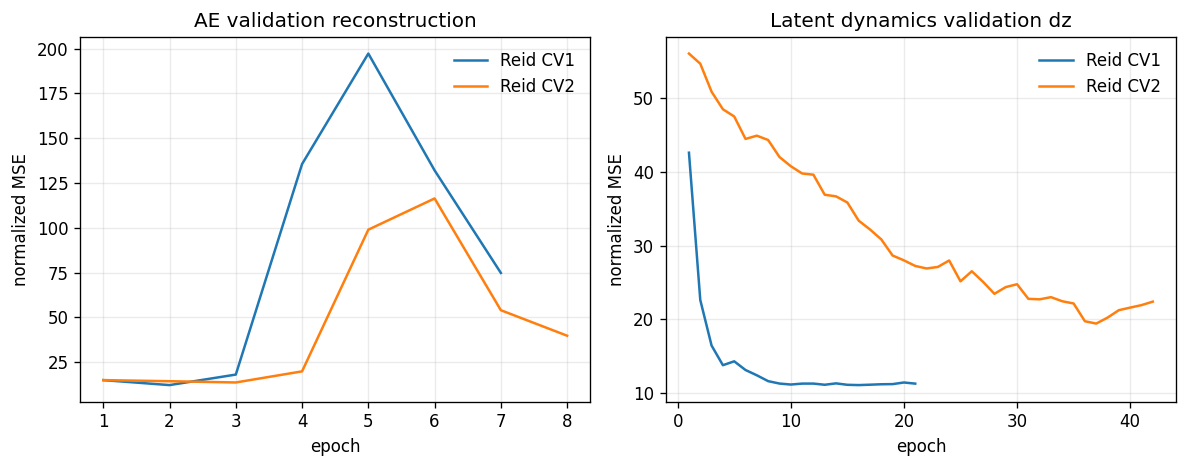

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for label, group in ae_history_df.groupby('dataset', sort=False):
    axes[0].plot(group['epoch'], group['val_mse_norm'], label=label)
for label, group in dyn_history_df.groupby('dataset', sort=False):
    axes[1].plot(group['epoch'], group['val_dz_mse_norm'], label=label)
axes[0].set_title('AE validation reconstruction')
axes[1].set_title('Latent dynamics validation dz')
for ax in axes:
    ax.set_xlabel('epoch')
    ax.set_ylabel('normalized MSE')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
plt.tight_layout()


## Rollout Quality

Decode latent rollouts and compare predicted p-ratio/positions against ground truth. This is the simulator test.



In [ ]:
decoded_eval_steps = 80


def use_result_stats(result):
    stats = result['stats']
    global delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode
    delta_mean = stats['delta_mean'].to(device)
    delta_std = stats['delta_std'].to(device)
    node_feature_mode = result['params'].get('node_feature_mode', 'delta')
    node_feature_mean = stats.get('node_feature_mean', stats['delta_mean']).to(device)
    node_feature_std = stats.get('node_feature_std', stats['delta_std']).to(device)
    edge_mean = stats['edge_mean'].to(device)
    edge_std = stats['edge_std'].to(device)
    latent_stats = {
        'z_mean': stats['z_mean'].to(device),
        'z_std': stats['z_std'].to(device),
        'dz_mean': stats['dz_mean'].to(device),
        'dz_std': stats['dz_std'].to(device),
    }


def span_strain(ref_graph, graph, axis):
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].detach().cpu().float()
    cur_pos = graph.x[:, :cfg['pos_dim']].detach().cpu().float()
    ref_span = float(ref_pos[:, axis].max() - ref_pos[:, axis].min())
    cur_span = float(cur_pos[:, axis].max() - cur_pos[:, axis].min())
    if abs(ref_span) <= 1e-12:
        return float('nan')
    return (cur_span - ref_span) / abs(ref_span)


def finite_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return float('nan')
    return r2_score(y_true[mask], y_pred[mask])


def finite_pearson(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return float('nan')
    return pearson_r(y_true[mask], y_pred[mask])


def decoded_rollout_rows(result, sims, *, split, max_steps):
    use_result_stats(result)
    ae_model = result['ae']
    dyn_model = result['dyn']
    ae_model.eval(); dyn_model.eval()
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            steps = min(int(max_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
            z = encode_frame(ae_model, sim, 0, device=device)
            ref_graph_cpu = clone_graph(sim[0]).cpu()
            initial_pos = ref_graph_cpu.x[:, :cfg['pos_dim']].cpu().float()
            for step_idx in range(steps + 1):
                target_index = frame_for_filtered_step(sim, step_idx)
                pred_graph = decode_latent_to_graph(ae_model, sim, z, target_index, device=device)
                pred_pos = pred_graph.x[:, :cfg['pos_dim']].cpu().float()
                true_graph = clone_graph(sim[target_index]).cpu()
                true_pos = true_graph.x[:, :cfg['pos_dim']].cpu().float()
                true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
                pred_pr = float(calc_p_ratio_rollout_sides([ref_graph_cpu, pred_graph], -1))
                true_x_strain = span_strain(ref_graph_cpu, true_graph, axis=0)
                pred_x_strain = span_strain(ref_graph_cpu, pred_graph, axis=0)
                true_y_strain = span_strain(ref_graph_cpu, true_graph, axis=1)
                pred_y_strain = span_strain(ref_graph_cpu, pred_graph, axis=1)
                initial_to_true = float(F.mse_loss(initial_pos, true_pos).item())
                rows.append({
                    'dataset': result['label'],
                    'latent_dim': int(result['params']['latent_dim']),
                    'split': split,
                    'sim_idx': int(sim_idx),
                    'step': int(step_idx),
                    'target_index': int(target_index),
                    'true_p_ratio': true_pr,
                    'pred_p_ratio': pred_pr,
                    'p_ratio_error': pred_pr - true_pr,
                    'true_horizontal_strain': true_x_strain,
                    'pred_horizontal_strain': pred_x_strain,
                    'horizontal_strain_error': pred_x_strain - true_x_strain,
                    'true_vertical_strain': true_y_strain,
                    'pred_vertical_strain': pred_y_strain,
                    'vertical_strain_error': pred_y_strain - true_y_strain,
                    'pos_mse': float(F.mse_loss(pred_pos, true_pos).item()),
                    'initial_to_true_mse': initial_to_true,
                    'movement_fraction_mse': float(F.mse_loss(pred_pos, initial_pos).item()) / initial_to_true if initial_to_true > 0 else float('nan'),
                })
                if step_idx < steps:
                    z = latent_step(dyn_model, z)
    return pd.DataFrame(rows)


decoded_step_df = pd.concat([
    decoded_rollout_rows(result, result['test_data'], split='test', max_steps=decoded_eval_steps)
    for result in source_results
], ignore_index=True)

decoded_step_summary_df = (
    decoded_step_df.groupby(['dataset', 'latent_dim', 'step'], as_index=False)
    .agg(
        pos_mse=('pos_mse', 'mean'),
        p_ratio_mae=('p_ratio_error', lambda x: float(np.nanmean(np.abs(x)))),
        p_ratio_rmse=('p_ratio_error', lambda x: float(np.sqrt(np.nanmean(np.square(x))))),
        horizontal_strain_mae=('horizontal_strain_error', lambda x: float(np.nanmean(np.abs(x)))),
        horizontal_strain_rmse=('horizontal_strain_error', lambda x: float(np.sqrt(np.nanmean(np.square(x))))),
        vertical_strain_mae=('vertical_strain_error', lambda x: float(np.nanmean(np.abs(x)))),
        movement_fraction_mse=('movement_fraction_mse', 'mean'),
    )
)

available_decoded_steps = sorted(decoded_step_df['step'].dropna().astype(int).unique())
if available_decoded_steps:
    decoded_eval_step_actual = min(available_decoded_steps, key=lambda step: abs(step - int(decoded_eval_steps)))
else:
    decoded_eval_step_actual = int(decoded_eval_steps)
if decoded_eval_step_actual != int(decoded_eval_steps):
    print(f'Requested decoded rollout step {decoded_eval_steps}, using closest available step {decoded_eval_step_actual}.')

final_decoded_step_df = decoded_step_df[decoded_step_df['step'].eq(decoded_eval_step_actual)].copy()
decoded_final_metrics_df = []
for dataset, group in final_decoded_step_df.groupby('dataset', sort=False):
    decoded_final_metrics_df.append({
        'dataset': dataset,
        'latent_dim': int(group['latent_dim'].iloc[0]),
        'requested_step': int(decoded_eval_steps),
        'step': int(decoded_eval_step_actual),
        'p_ratio_r2': finite_r2(group['true_p_ratio'], group['pred_p_ratio']),
        'p_ratio_pearson': finite_pearson(group['true_p_ratio'], group['pred_p_ratio']),
        'horizontal_strain_r2': finite_r2(group['true_horizontal_strain'], group['pred_horizontal_strain']),
        'horizontal_strain_pearson': finite_pearson(group['true_horizontal_strain'], group['pred_horizontal_strain']),
        'pos_mse': float(group['pos_mse'].mean()),
    })
decoded_final_metrics_df = pd.DataFrame(decoded_final_metrics_df)

display(decoded_step_summary_df.groupby(['dataset', 'latent_dim'], as_index=False).tail(1).round(5))
display(decoded_final_metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.2))
for label, group in decoded_step_summary_df.groupby('dataset', sort=False):
    axes[0].plot(group['step'], group['pos_mse'], label=label)
    axes[1].plot(group['step'], group['p_ratio_mae'], label=label)
    axes[2].plot(group['step'], group['horizontal_strain_mae'], label=label)
axes[0].set_title('Decoded rollout position error')
axes[0].set_ylabel('mean position MSE')
axes[1].set_title('Decoded rollout p-ratio error')
axes[1].set_ylabel('mean absolute p-ratio error')
axes[2].set_title('Decoded rollout x-strain error')
axes[2].set_ylabel('mean absolute horizontal strain error')
for ax in axes:
    ax.set_xlabel('decoded rollout step')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
plt.tight_layout()

rollout_scatter_df = decoded_step_df[decoded_step_df['step'] == decoded_eval_step_actual].copy()
rollout_groups = list(rollout_scatter_df.groupby('dataset', sort=False))
if not rollout_groups:
    print(f'No decoded rollout rows found at step {decoded_eval_step_actual}; skipping rollout p-ratio scatter.')
else:
    fig, axes = plt.subplots(1, len(rollout_groups), figsize=(5.2 * len(rollout_groups), 4.8), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    lo = float(np.nanmin([rollout_scatter_df['true_p_ratio'].min(), rollout_scatter_df['pred_p_ratio'].min()]))
    hi = float(np.nanmax([rollout_scatter_df['true_p_ratio'].max(), rollout_scatter_df['pred_p_ratio'].max()]))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    for ax, (label, group) in zip(axes, rollout_groups):
        rollout_r = finite_pearson(group['true_p_ratio'], group['pred_p_ratio'])
        rollout_r2 = finite_r2(group['true_p_ratio'], group['pred_p_ratio'])
        ax.scatter(group['true_p_ratio'], group['pred_p_ratio'], s=28, alpha=0.8)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color='black', lw=1, alpha=0.6)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xlabel('ground-truth p-ratio')
        ax.set_title(f'{label}: latent rollout decode step {decoded_eval_step_actual}\nPearson r={rollout_r:.3f}, R2={rollout_r2:.3f}')
        ax.grid(alpha=0.25)
    axes[0].set_ylabel('decoded rollout p-ratio')
    fig.suptitle('Decoded latent rollout p-ratio vs ground truth', fontsize=13, fontweight='bold')
    plt.tight_layout()

# Does the decoded trajectory reproduce the ground-truth P-vs-x-strain path?
p_vs_strain_sample_count = 8
p_vs_strain_groups = list(decoded_step_df.groupby('dataset', sort=False))
if not p_vs_strain_groups:
    print('No decoded rollout rows found; skipping P-vs-x-strain path plot.')
else:
    fig, axes = plt.subplots(1, len(p_vs_strain_groups), figsize=(5.4 * len(p_vs_strain_groups), 4.8), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (label, group) in zip(axes, p_vs_strain_groups):
        sample_ids = sorted(group['sim_idx'].unique())[:p_vs_strain_sample_count]
        for sim_idx in sample_ids:
            traj = group[group['sim_idx'].eq(sim_idx)].sort_values('step')
            valid_true = traj[['true_horizontal_strain', 'true_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
            valid_pred = traj[['pred_horizontal_strain', 'pred_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
            if len(valid_true) >= 2:
                ax.plot(valid_true['true_horizontal_strain'], valid_true['true_p_ratio'], color='black', alpha=0.28, lw=1.1)
            if len(valid_pred) >= 2:
                ax.plot(valid_pred['pred_horizontal_strain'], valid_pred['pred_p_ratio'], alpha=0.76, lw=1.35)
        final_group = group[group['step'].eq(decoded_eval_step_actual)]
        pr_r2 = finite_r2(final_group['true_p_ratio'], final_group['pred_p_ratio'])
        xs_r2 = finite_r2(final_group['true_horizontal_strain'], final_group['pred_horizontal_strain'])
        ax.set_title(f'{label}: P vs x-strain\nstep {decoded_eval_step_actual}: p-ratio R2={pr_r2:.3f}, x-strain R2={xs_r2:.3f}')
        ax.set_xlabel('horizontal strain from initial graph')
        ax.grid(alpha=0.25)
    axes[0].set_ylabel('p-ratio')
    fig.suptitle('Ground truth paths in black; decoded rollout paths in color', fontsize=13, fontweight='bold')
    plt.tight_layout()







## Latent Readout Of P-ratio

Encode test trajectories, compute raw latent variables and PCA axes, then compare three p-ratio readouts: best single latent, PC1, and a supervised linear combination of all latent variables.



,dataset,latent_dim,pc,explained_var,corr_p_ratio,corr_trajectory_progress,corr_final_p_ratio
0,Reid CV1,1,pc1,1.0,-0.4277,0.6703,-0.3625
1,Reid CV2,2,pc1,1.0,-0.5019,0.8432,-0.4244
2,Reid CV2,2,pc2,0.0,0.7269,0.4185,0.7585


cv                z0      z1
dataset  pc                 
Reid CV1 pc1  1.0000     NaN
Reid CV2 pc1  0.5967 -0.8025
         pc2 -0.8025 -0.5967

,dataset,cv,corr_current_p_ratio,corr_final_p_ratio,corr_trajectory_progress,role
0,Reid CV1,z0,-0.4277,-0.3625,0.6703,p-ratio CV
1,Reid CV2,z0,-0.5081,-0.4309,0.8395,p-ratio CV
2,Reid CV2,z1,0.4984,0.4208,-0.8452,phase CV


,dataset,signal,corr_final_p_ratio,corr_mean_frame_p_ratio
1,Reid CV1,initial_pc1,0.8880,0.8973
0,Reid CV1,initial_z0,0.8880,0.8973
2,Reid CV1,initial_z1,NaN,NaN
3,Reid CV1,initial_pc2,NaN,NaN
6,Reid CV2,initial_z1,0.8849,0.8954
5,Reid CV2,initial_pc1,-0.8848,-0.8954
4,Reid CV2,initial_z0,-0.8846,-0.8952
7,Reid CV2,initial_pc2,0.8788,0.8900


,dataset,sim_idx,final_p_ratio,mean_frame_p_ratio,final_frame_p_ratio,initial_z0,mean_z0,final_z0,slope_z0,initial_pc1,...,final_pc1,slope_pc1,initial_z1,mean_z1,final_z1,slope_z1,initial_pc2,mean_pc2,final_pc2,slope_pc2
0,Reid CV1,0,-0.1277,-0.1047,-0.1274,2.9015,15.6991,32.4570,29.5555,-14.9572,...,14.5983,29.5555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Reid CV1,1,-0.1319,-0.1102,-0.1316,2.9399,17.3564,38.1745,35.2346,-14.9188,...,20.3158,35.2346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Reid CV1,2,0.3874,0.3876,0.3873,3.4502,9.8584,16.6623,13.2121,-14.4085,...,-1.1964,13.2121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Reid CV1,3,-0.1571,-0.1339,-0.1568,2.9661,17.0646,35.7869,32.8208,-14.8926,...,17.9282,32.8208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Reid CV1,4,-0.1535,-0.1364,-0.1532,2.8041,24.5477,61.4677,58.6636,-15.0546,...,43.6090,58.6636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Reid CV2,67,-0.1981,-0.1648,-0.1976,5.4943,12.7902,21.5812,16.0869,-10.1131,...,16.9855,27.0986,-6.1304,-16.0372,-27.9376,-21.8073,-0.1243,-0.0676,-0.0212,0.1031
140,Reid CV2,68,-0.3340,-0.2784,-0.3332,4.9825,13.7246,25.2262,20.2438,-10.9195,...,23.1486,34.0680,-5.5061,-17.3652,-32.9075,-27.4013,-0.0860,-0.0250,0.0193,0.1054
141,Reid CV2,69,0.2767,0.2776,0.2767,3.9511,8.9143,14.1114,10.1603,-12.5203,...,4.6005,17.1208,-4.2781,-11.0150,-18.0583,-13.7802,0.0088,0.0459,0.0782,0.0693
142,Reid CV2,70,0.1818,0.1840,0.1819,3.5860,8.8074,14.2200,10.6340,-13.0941,...,4.8370,17.9311,-3.8346,-10.9262,-18.2723,-14.4377,0.0371,0.0787,0.1187,0.0815


,dataset,signal,target,fit_split,eval_split,intercept,formula,val_pearson_r,val_r2,test_pearson_r,test_r2,weight_initial_z0,weight_initial_z1
0,Reid CV1,initial_z_linear_p_ratio,final_p_ratio,val,test,-2.8328,1*z0,0.776,0.6021,0.8880,0.7864,1.0000,NaN
1,Reid CV2,initial_z_linear_p_ratio,final_p_ratio,val,test,1.9022,-0.82*z0 - 0.58*z1,0.810,0.6562,0.8811,0.7745,-0.8151,-0.5793


,dataset,signal,source,fit_split,eval_split,val_corr_final_p_ratio,val_r2_final_p_ratio,corr_final_p_ratio,r2_final_p_ratio
0,Reid CV1,initial_z0,single_latent_val_selected,val,test,0.7760,0.6021,0.8880,0.7864
1,Reid CV1,initial_z_linear_p_ratio,val_linear_combo,val,test,0.7760,0.6021,0.8880,0.7864
4,Reid CV2,initial_z_linear_p_ratio,val_linear_combo,val,test,0.8100,0.6562,0.8811,0.7745
2,Reid CV2,initial_z0,single_latent_val_selected,val,test,-0.8072,0.6516,-0.8846,0.7802
3,Reid CV2,initial_z1,single_latent_val_selected,val,test,0.8061,0.6498,0.8849,0.7805


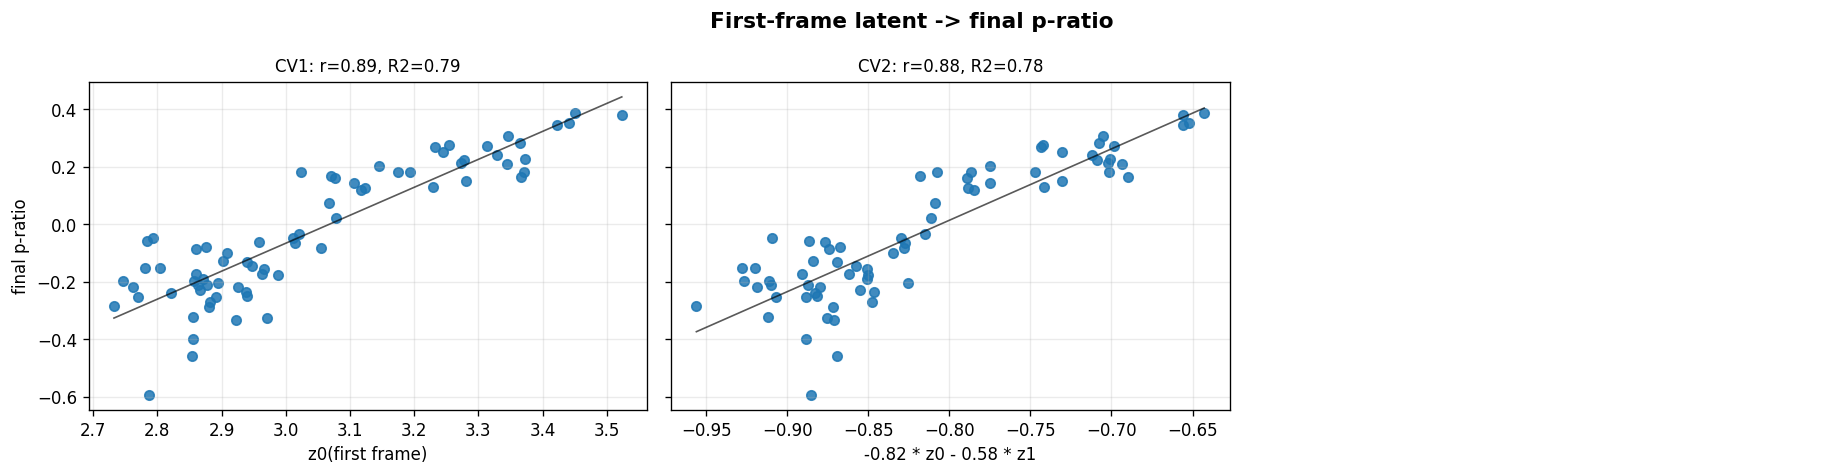

In [ ]:
pca_analysis_split = 'test'
pca_analysis_max_frames = None


def latent_frame_table(result, sims, *, split, max_frames=None):
    use_result_stats(result)
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=max_frames)
            frame_count = len(frame_ids)
            final_p_ratio = float(calc_p_ratio_rollout_sides(sim, -1))
            for frame_order, frame_idx in enumerate(frame_ids):
                z = encode_frame(result['ae'], sim, frame_idx, device=device).detach().cpu().numpy().reshape(-1)
                row = {
                    'dataset': result['label'],
                    'latent_dim': int(result['params']['latent_dim']),
                    'split': split,
                    'sim_idx': int(sim_idx),
                    'frame': int(frame_idx),
                    'frame_frac': float(frame_order / max(frame_count - 1, 1)),
                    'p_ratio': float(calc_p_ratio_rollout_sides(sim, frame_idx)),
                    'final_p_ratio': final_p_ratio,
                }
                for dim_idx, value in enumerate(z):
                    row[f'z{dim_idx}'] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)


def safe_corr(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    if len(a) < 2 or np.isclose(a.std(), 0.0) or np.isclose(b.std(), 0.0):
        return float('nan')
    return float(a.corr(b))


def safe_linear_fit_1d(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    valid = np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid]
    y_valid = y[valid]
    if len(x_valid) == 0:
        return 0.0, 0.0
    if len(x_valid) < 2 or np.isclose(np.std(x_valid), 0.0):
        return 0.0, float(np.mean(y_valid))
    X = np.column_stack([x_valid, np.ones(len(x_valid))])
    try:
        coef, *_ = np.linalg.lstsq(X, y_valid, rcond=None)
        slope, intercept = float(coef[0]), float(coef[1])
    except np.linalg.LinAlgError:
        slope, intercept = 0.0, float(np.mean(y_valid))
    if not np.isfinite(slope) or not np.isfinite(intercept):
        slope, intercept = 0.0, float(np.mean(y_valid))
    return slope, intercept

latent_frame_tables = []
pca_rows = []
pca_loading_frames = []
for result in source_results:
    df_z = latent_frame_table(result, result[f'{pca_analysis_split}_data'], split=pca_analysis_split, max_frames=pca_analysis_max_frames)
    z_cols = [c for c in df_z.columns if c.startswith('z')]
    if len(df_z) < 2 or not z_cols:
        continue
    Z = df_z[z_cols].to_numpy(dtype=float)
    Z_centered = Z - Z.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(Z_centered, full_matrices=False)
    scores = Z_centered @ vt.T
    explained = singular_values**2
    explained = explained / explained.sum() if explained.sum() > 0 else np.zeros_like(explained)
    for pc_idx in range(scores.shape[1]):
        pc_col = f'pc{pc_idx + 1}'
        df_z[pc_col] = scores[:, pc_idx]
        pca_rows.append({
            'dataset': result['label'],
            'latent_dim': int(result['params']['latent_dim']),
            'pc': pc_col,
            'explained_var': float(explained[pc_idx]),
            'corr_p_ratio': safe_corr(df_z[pc_col], df_z['p_ratio']),
            'corr_trajectory_progress': safe_corr(df_z[pc_col], df_z['frame_frac']),
            'corr_final_p_ratio': safe_corr(df_z[pc_col], df_z['final_p_ratio']),
        })
        for cv_idx, cv_col in enumerate(z_cols):
            pca_loading_frames.append({
                'dataset': result['label'],
                'pc': pc_col,
                'cv': cv_col,
                'loading': float(vt[pc_idx, cv_idx]),
            })
    latent_frame_tables.append(df_z)

    # PCA scores/loadings are kept for downstream tables, but the exploratory PCA scatter plot is intentionally omitted.

latent_frame_df = pd.concat(latent_frame_tables, ignore_index=True) if latent_frame_tables else pd.DataFrame()
pca_relation_df = pd.DataFrame(pca_rows)
pca_loading_df = pd.DataFrame(pca_loading_frames)
display(pca_relation_df.round(4))
display(pca_loading_df.pivot_table(index=['dataset', 'pc'], columns='cv', values='loading').round(4))


def infer_cv_roles(frame_df):
    rows = []
    role_rows = []
    for dataset, group in frame_df.groupby('dataset', sort=False):
        z_cols = [col for col in group.columns if col.startswith('z') and group[col].notna().any()]
        if not z_cols:
            continue
        corr_rows = []
        for cv_col in z_cols:
            corr_current = safe_corr(group[cv_col], group['p_ratio'])
            corr_final = safe_corr(group[cv_col], group['final_p_ratio'])
            corr_frame = safe_corr(group[cv_col], group['frame_frac'])
            corr_rows.append({
                'dataset': dataset,
                'cv': cv_col,
                'corr_current_p_ratio': corr_current,
                'corr_final_p_ratio': corr_final,
                'corr_trajectory_progress': corr_frame,
                'p_ratio_score': np.nanmax([abs(corr_current), abs(corr_final)]),
                'phase_score': abs(corr_frame),
            })
        corr_df = pd.DataFrame(corr_rows)
        p_ratio_cv = corr_df.sort_values('p_ratio_score', ascending=False)['cv'].iloc[0]
        remaining = corr_df[corr_df['cv'] != p_ratio_cv]
        phase_cv = remaining.sort_values('phase_score', ascending=False)['cv'].iloc[0] if not remaining.empty else None
        corr_df['role'] = corr_df['cv'].map(lambda cv: 'p-ratio CV' if cv == p_ratio_cv else ('phase CV' if cv == phase_cv else 'other'))
        rows.extend(corr_df.to_dict('records'))
        role_rows.append({'dataset': dataset, 'p_ratio_cv': p_ratio_cv, 'phase_cv': phase_cv})
    return pd.DataFrame(rows), pd.DataFrame(role_rows)


cv_role_corr_df, cv_role_df = infer_cv_roles(latent_frame_df)
display(cv_role_corr_df.drop(columns=['p_ratio_score', 'phase_score']).round(4))


# Trajectory-level aggregation. For p-ratio prediction, use only the first-frame
# latent coordinate so the readout is a single-snapshot geometry test.
trajectory_corr_rows = []
trajectory_mean_frames = []
if not latent_frame_df.empty:
    value_cols = [col for col in latent_frame_df.columns if col.startswith('z') or col.startswith('pc')]
    for (dataset, sim_idx), group in latent_frame_df.groupby(['dataset', 'sim_idx'], sort=False):
        row = {
            'dataset': dataset,
            'sim_idx': int(sim_idx),
            'final_p_ratio': float(group['final_p_ratio'].iloc[0]),
            'mean_frame_p_ratio': float(group['p_ratio'].mean()),
            'final_frame_p_ratio': float(group['p_ratio'].iloc[-1]),
        }
        for col in value_cols:
            row[f'initial_{col}'] = float(group[col].iloc[0])
            row[f'mean_{col}'] = float(group[col].mean())
            row[f'final_{col}'] = float(group[col].iloc[-1])
            row[f'slope_{col}'] = float(group[col].iloc[-1] - group[col].iloc[0])
        trajectory_mean_frames.append(row)

trajectory_mean_df = pd.DataFrame(trajectory_mean_frames)
if not trajectory_mean_df.empty:
    for dataset, group in trajectory_mean_df.groupby('dataset', sort=False):
        signal_cols = [col for col in trajectory_mean_df.columns if col.startswith(('initial_z', 'initial_pc'))]
        for signal_col in signal_cols:
            trajectory_corr_rows.append({
                'dataset': dataset,
                'signal': signal_col,
                'corr_final_p_ratio': safe_corr(group[signal_col], group['final_p_ratio']),
                'corr_mean_frame_p_ratio': safe_corr(group[signal_col], group['mean_frame_p_ratio']),
            })

trajectory_corr_df = pd.DataFrame(trajectory_corr_rows)
if trajectory_corr_rows:
    display(
        trajectory_corr_df
        .assign(abs_corr_final_p_ratio=lambda df: df['corr_final_p_ratio'].abs())
        .sort_values(['dataset', 'abs_corr_final_p_ratio'], ascending=[True, False])
        .drop(columns='abs_corr_final_p_ratio')
        .round(4)
    )
    display(trajectory_mean_df.round(4))

    def pc_loading_formula(dataset, signal_col):
        pc_name = signal_col.replace('initial_', '').replace('mean_', '').replace('final_', '').replace('slope_', '')
        if not pc_name.startswith('pc') or pca_loading_df.empty:
            return ''
        rows = pca_loading_df[(pca_loading_df['dataset'] == dataset) & (pca_loading_df['pc'] == pc_name)]
        if rows.empty:
            return ''
        terms = []
        for _, loading_row in rows.sort_values('cv').iterrows():
            weight = float(loading_row['loading'])
            cv = loading_row['cv']
            if not terms:
                terms.append(f'{weight:.2f}*{cv}')
            else:
                sign = '+' if weight >= 0 else '-'
                terms.append(f' {sign} {abs(weight):.2f}*{cv}')
        return f" ({pc_name.upper()} = {''.join(terms)})"

    def first_frame_trajectory_table(result, sims, *, split):
        use_result_stats(result)
        rows = []
        with torch.no_grad():
            for sim_idx, sim in enumerate(sims):
                z = encode_frame(result['ae'], sim, 0, device=device).detach().cpu().numpy().reshape(-1)
                row = {
                    'dataset': result['label'],
                    'latent_dim': int(result['params']['latent_dim']),
                    'split': split,
                    'sim_idx': int(sim_idx),
                    'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
                }
                for dim_idx, value in enumerate(z):
                    row[f'initial_z{dim_idx}'] = float(value)
                rows.append(row)
        return pd.DataFrame(rows)


    trajectory_val_df = pd.concat(
        [first_frame_trajectory_table(result, result['val_data'], split='val') for result in source_results],
        ignore_index=True,
    ) if source_results else pd.DataFrame()


    def fit_val_linear_combo_signal(fit_group, eval_group, feature_cols, target_col='final_p_ratio'):
        X_fit = fit_group[feature_cols].to_numpy(dtype=float)
        y_fit = fit_group[target_col].to_numpy(dtype=float)
        X_eval = eval_group[feature_cols].to_numpy(dtype=float)
        y_eval = eval_group[target_col].to_numpy(dtype=float)
        fit_mask = np.isfinite(y_fit) & np.all(np.isfinite(X_fit), axis=1)
        eval_mask = np.isfinite(y_eval) & np.all(np.isfinite(X_eval), axis=1)
        signal = np.full(len(eval_group), np.nan, dtype=float)
        coef = np.full(len(feature_cols), np.nan, dtype=float)
        intercept = np.nan
        val_r = np.nan
        val_r2 = np.nan
        test_r = np.nan
        test_r2 = np.nan
        if fit_mask.sum() >= len(feature_cols) + 2 and eval_mask.sum() >= 2 and not np.isclose(np.std(y_fit[fit_mask]), 0.0):
            X_design = np.column_stack([np.ones(fit_mask.sum()), X_fit[fit_mask]])
            beta, *_ = np.linalg.lstsq(X_design, y_fit[fit_mask], rcond=None)
            raw_coef = beta[1:].astype(float)
            norm = float(np.linalg.norm(raw_coef))
            if norm > 1e-12 and np.isfinite(norm):
                coef = raw_coef / norm
                fit_signal = X_fit[fit_mask] @ coef
                signal[eval_mask] = X_eval[eval_mask] @ coef
                val_r = safe_corr(fit_signal, y_fit[fit_mask])
                slope, intercept = safe_linear_fit_1d(fit_signal, y_fit[fit_mask])
                val_pred = slope * fit_signal + intercept
                eval_pred = slope * signal[eval_mask] + intercept
                val_r2 = r2_score(y_fit[fit_mask], val_pred)
                test_r = safe_corr(signal[eval_mask], y_eval[eval_mask])
                test_r2 = r2_score(y_eval[eval_mask], eval_pred)
        return signal, coef, intercept, val_r, val_r2, test_r, test_r2


    def val_fit_test_score(fit_group, eval_group, signal_col, target_col='final_p_ratio'):
        x_fit = fit_group[signal_col].to_numpy(dtype=float)
        y_fit = fit_group[target_col].to_numpy(dtype=float)
        x_eval = eval_group[signal_col].to_numpy(dtype=float)
        y_eval = eval_group[target_col].to_numpy(dtype=float)
        fit_mask = np.isfinite(x_fit) & np.isfinite(y_fit)
        eval_mask = np.isfinite(x_eval) & np.isfinite(y_eval)
        if fit_mask.sum() < 2 or eval_mask.sum() < 2:
            return np.nan, np.nan, np.nan, np.nan
        val_r = safe_corr(x_fit[fit_mask], y_fit[fit_mask])
        slope, intercept = safe_linear_fit_1d(x_fit[fit_mask], y_fit[fit_mask])
        val_pred = slope * x_fit[fit_mask] + intercept
        eval_pred = slope * x_eval[eval_mask] + intercept
        test_r = safe_corr(x_eval[eval_mask], y_eval[eval_mask])
        return val_r, r2_score(y_fit[fit_mask], val_pred), test_r, r2_score(y_eval[eval_mask], eval_pred)


    supervised_axis_rows = []
    p_ratio_signal_rows = []
    for dataset, group_idx in trajectory_mean_df.groupby('dataset', sort=False).groups.items():
        group = trajectory_mean_df.loc[group_idx]
        val_group = trajectory_val_df[trajectory_val_df['dataset'].eq(dataset)].copy() if not trajectory_val_df.empty else pd.DataFrame()
        initial_z_cols = [col for col in group.columns if col.startswith('initial_z') and group[col].notna().any()]
        initial_z_cols = [col for col in initial_z_cols if col in val_group.columns] if not val_group.empty else initial_z_cols
        if initial_z_cols and not val_group.empty:
            signal, coef, intercept, val_r, val_r2, test_r, test_r2 = fit_val_linear_combo_signal(val_group, group, initial_z_cols)
            trajectory_mean_df.loc[group_idx, 'initial_z_linear_p_ratio'] = signal
            terms = []
            for col, w in zip(initial_z_cols, coef):
                short_col = col.replace('initial_', '')
                if not terms:
                    terms.append(f'{w:.2g}*{short_col}')
                else:
                    sign = '+' if w >= 0 else '-'
                    terms.append(f' {sign} {abs(w):.2g}*{short_col}')
            formula = ''.join(terms)
            supervised_axis_rows.append({
                'dataset': dataset,
                'signal': 'initial_z_linear_p_ratio',
                'target': 'final_p_ratio',
                'fit_split': 'val',
                'eval_split': 'test',
                'intercept': intercept,
                'formula': formula,
                'val_pearson_r': val_r,
                'val_r2': val_r2,
                'test_pearson_r': test_r,
                'test_r2': test_r2,
                **{f'weight_{col}': float(w) for col, w in zip(initial_z_cols, coef)},
            })

        candidate_cols = []
        candidate_cols.extend([col for col in initial_z_cols if col in group.columns])
        if 'initial_z_linear_p_ratio' in trajectory_mean_df.columns:
            candidate_cols.append('initial_z_linear_p_ratio')
        candidate_cols = list(dict.fromkeys(candidate_cols))
        for signal_col in candidate_cols:
            if val_group.empty or signal_col not in val_group.columns and signal_col != 'initial_z_linear_p_ratio':
                continue
            if signal_col == 'initial_z_linear_p_ratio':
                axis_row = next((row for row in supervised_axis_rows if row['dataset'] == dataset), None)
                val_r = axis_row['val_pearson_r'] if axis_row else np.nan
                val_r2 = axis_row['val_r2'] if axis_row else np.nan
                test_r = axis_row['test_pearson_r'] if axis_row else np.nan
                test_r2 = axis_row['test_r2'] if axis_row else np.nan
                source = 'val_linear_combo'
            else:
                val_r, val_r2, test_r, test_r2 = val_fit_test_score(val_group, group, signal_col)
                source = 'single_latent_val_selected'
            p_ratio_signal_rows.append({
                'dataset': dataset,
                'signal': signal_col,
                'source': source,
                'fit_split': 'val',
                'eval_split': 'test',
                'val_corr_final_p_ratio': val_r,
                'val_r2_final_p_ratio': val_r2,
                'corr_final_p_ratio': test_r,
                'r2_final_p_ratio': test_r2,
                'abs_val_corr_final_p_ratio': abs(val_r) if np.isfinite(val_r) else np.nan,
            })

    supervised_axis_df = pd.DataFrame(supervised_axis_rows)
    p_ratio_signal_df = pd.DataFrame(p_ratio_signal_rows)
    best_p_ratio_signal_df = (
        p_ratio_signal_df
        .sort_values(['dataset', 'abs_val_corr_final_p_ratio'], ascending=[True, False])
        .groupby('dataset', as_index=False)
        .head(1)
        .drop(columns='abs_val_corr_final_p_ratio')
    ) if not p_ratio_signal_df.empty else pd.DataFrame()
    if not supervised_axis_df.empty:
        display(supervised_axis_df.round(4))
    if not p_ratio_signal_df.empty:
        display(
            p_ratio_signal_df
            .sort_values(['dataset', 'abs_val_corr_final_p_ratio'], ascending=[True, False])
            .drop(columns='abs_val_corr_final_p_ratio')
            .round(4)
        )

    def compact_cv_label(dataset):
        text = str(dataset)
        for token in text.split():
            if token.upper().startswith('CV'):
                return token.upper()
        return text

    def compact_formula(formula):
        text = str(formula)
        text = text.replace('initial_', '')
        text = text.replace('*', ' * ')
        text = text.replace(' + -', ' - ')
        text = text.replace('+ -', '- ')
        return text

    def signal_label(dataset, signal_col, source):
        if 'linear_combo' in str(source) and 'supervised_axis_df' in globals() and not supervised_axis_df.empty:
            match = supervised_axis_df[
                (supervised_axis_df['dataset'].eq(dataset))
                & (supervised_axis_df['signal'].eq(signal_col))
            ]
            if not match.empty:
                return compact_formula(match['formula'].iloc[0])
        if signal_col.startswith('initial_'):
            return signal_col.replace('initial_', '') + '(first frame)'
        return signal_col

    cv_pratio_groups = list(trajectory_mean_df.groupby('dataset', sort=False))
    n_cols = 3
    n_rows = int(np.ceil(len(cv_pratio_groups) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.1 * n_cols, 4.0 * n_rows), sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, (dataset, group) in zip(axes_flat, cv_pratio_groups):
        best_row = best_p_ratio_signal_df[best_p_ratio_signal_df['dataset'].eq(dataset)] if 'best_p_ratio_signal_df' in globals() else pd.DataFrame()
        preferred_x = best_row['signal'].iloc[0] if not best_row.empty else 'initial_z0'
        source = best_row['source'].iloc[0] if not best_row.empty else 'single_latent'
        ax.scatter(group[preferred_x], group['final_p_ratio'], s=32, alpha=0.85)
        corr = safe_corr(group[preferred_x], group['final_p_ratio'])
        slope, intercept = safe_linear_fit_1d(group[preferred_x], group['final_p_ratio'])
        cv_pred = slope * np.asarray(group[preferred_x], dtype=float) + intercept
        cv_r2 = r2_score(group['final_p_ratio'], cv_pred)
        x_valid = np.asarray(group[preferred_x], dtype=float)
        x_valid = x_valid[np.isfinite(x_valid)]
        if len(x_valid):
            x_line = np.linspace(float(x_valid.min()), float(x_valid.max()), 100)
            ax.plot(x_line, slope * x_line + intercept, color='black', lw=1, alpha=0.65)
        label = signal_label(dataset, preferred_x, source)
        if preferred_x == 'initial_pc1':
            label += pc_loading_formula(dataset, preferred_x)
        ax.set_xlabel(label)
        ax.set_title(f'{compact_cv_label(dataset)}: r={corr:.2f}, R2={cv_r2:.2f}', fontsize=10)
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(cv_pratio_groups):]:
        ax.axis('off')
    for row_ax in axes[:, 0]:
        row_ax.set_ylabel('final p-ratio')
    fig.suptitle('First-frame latent -> final p-ratio', fontsize=13, fontweight='bold')
    plt.tight_layout()

else:
    print('No trajectory-level PCA/CV correlation table was produced.')


## Latent-space Explanation

Explain what the learned latent space represents by comparing latent/PCA signals with physical quantities such as p-ratio, horizontal/vertical strain, trajectory progress, and displacement magnitudes.



Top latent/PCA physical correlations: Reid CV1


,dataset,signal,target,pearson_r
0,Reid CV1,z0,x_compression,0.6234
3,Reid CV1,pc1,x_compression,0.6234
1,Reid CV1,z0,y_compression,0.4357
4,Reid CV1,pc1,y_compression,0.4357
2,Reid CV1,z0,frame_p_ratio,-0.4277
5,Reid CV1,pc1,frame_p_ratio,-0.4277
6,Reid CV1,z1,x_compression,NaN
7,Reid CV1,z1,y_compression,NaN
8,Reid CV1,z1,frame_p_ratio,NaN
9,Reid CV1,pc2,x_compression,NaN



Top latent/PCA physical correlations: Reid CV2


,dataset,signal,target,pearson_r
18,Reid CV2,z1,x_compression,-0.7860
15,Reid CV2,pc1,x_compression,0.7840
12,Reid CV2,z0,x_compression,0.7805
23,Reid CV2,pc2,frame_p_ratio,0.7269
22,Reid CV2,pc2,y_compression,-0.5516
14,Reid CV2,z0,frame_p_ratio,-0.5081
17,Reid CV2,pc1,frame_p_ratio,-0.5019
20,Reid CV2,z1,frame_p_ratio,0.4984
13,Reid CV2,z0,y_compression,0.4794
16,Reid CV2,pc1,y_compression,0.4747


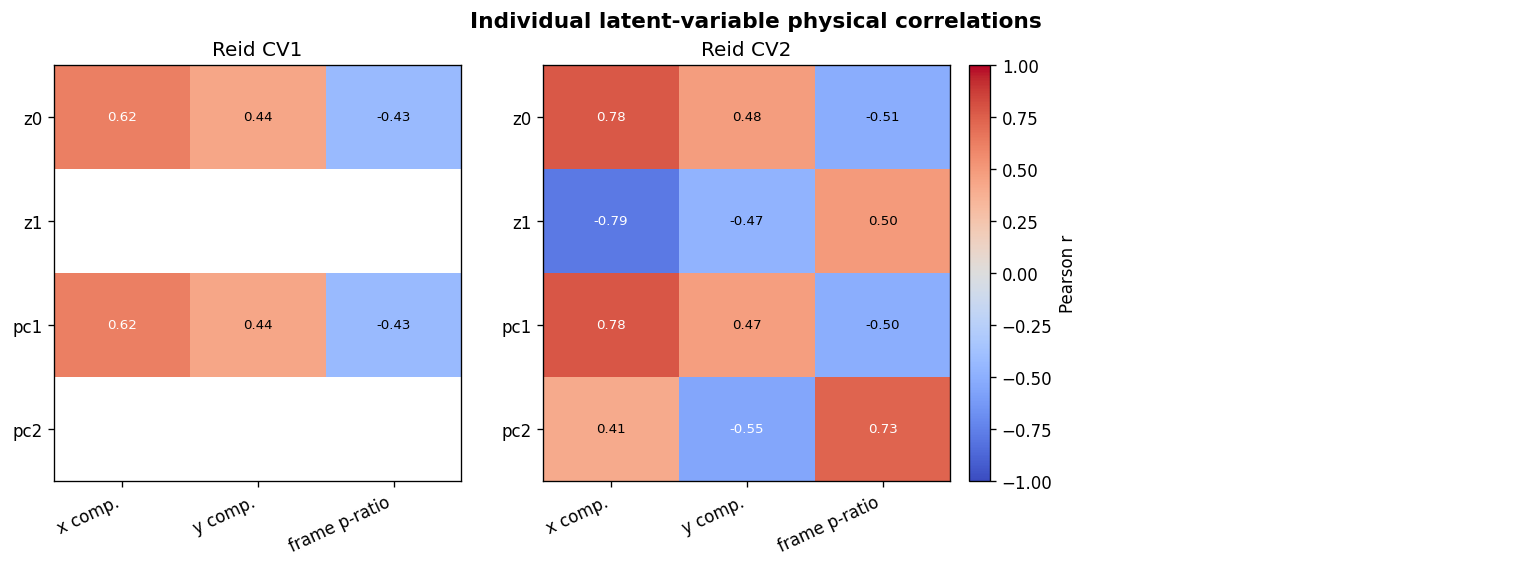

In [ ]:
physical_property_max_frames = None
latent_trajectory_max_sims = 14


def graph_physical_row(result, sim, sim_idx, frame_idx, frame_count):
    ref_graph = clone_graph(sim[0]).cpu()
    cur_graph = clone_graph(sim[frame_idx]).cpu()
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].cpu().float()
    cur_pos = cur_graph.x[:, :cfg['pos_dim']].cpu().float()
    disp = cur_pos - ref_pos
    return {
        'dataset': result['label'],
        'latent_dim': int(result['params']['latent_dim']),
        'split': 'test',
        'sim_idx': int(sim_idx),
        'frame': int(frame_idx),
        'trajectory_progress': float(frame_idx / max(frame_count - 1, 1)),
        'p_ratio': float(calc_p_ratio_rollout_sides(sim, frame_idx)),
        'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
        'horizontal_strain': span_strain(ref_graph, cur_graph, axis=0),
        'vertical_strain': span_strain(ref_graph, cur_graph, axis=1),
        'mean_abs_x_disp': float(disp[:, 0].abs().mean()),
        'mean_abs_y_disp': float(disp[:, 1].abs().mean()),
        'rms_disp': float(torch.sqrt((disp.square()).sum(dim=1).mean())),
    }


physical_property_rows = []
for result in source_results:
    for sim_idx, sim in enumerate(result['test_data']):
        frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=physical_property_max_frames)
        frame_count = len(frame_ids)
        for frame_idx in frame_ids:
            physical_property_rows.append(graph_physical_row(result, sim, sim_idx, frame_idx, len(sim)))
physical_property_df = pd.DataFrame(physical_property_rows)

latent_physical_df = latent_frame_df.merge(
    physical_property_df.drop(columns=['p_ratio', 'final_p_ratio']),
    on=['dataset', 'latent_dim', 'split', 'sim_idx', 'frame'],
    how='left',
)
latent_physical_df['x_compression'] = -latent_physical_df['horizontal_strain']
latent_physical_df['y_compression'] = -latent_physical_df['vertical_strain']
latent_physical_df['frame_p_ratio'] = latent_physical_df['p_ratio']

# 2D latent-space trajectory plot omitted; physical correlation matrices below are the main latent-space explanation.

# PCA/CV correlation to physical properties.
physical_targets = ['x_compression', 'y_compression', 'frame_p_ratio']
pca_physical_corr_rows = []
for dataset, group in latent_physical_df.groupby('dataset', sort=False):
    signal_cols = [col for col in group.columns if col.startswith('z') or col.startswith('pc')]
    for signal_col in signal_cols:
        for target_col in physical_targets:
            if target_col in group:
                pca_physical_corr_rows.append({
                    'dataset': dataset,
                    'signal': signal_col,
                    'target': target_col,
                    'pearson_r': safe_corr(group[signal_col], group[target_col]),
                })
pca_physical_corr_df = pd.DataFrame(pca_physical_corr_rows)

if not pca_physical_corr_df.empty:
    for dataset, corr_group in pca_physical_corr_df.groupby('dataset', sort=False):
        top = (
            corr_group.assign(abs_r=lambda df: df['pearson_r'].abs())
            .sort_values('abs_r', ascending=False)
            .drop(columns='abs_r')
            .head(12)
        )
        print(f'\nTop latent/PCA physical correlations: {dataset}')
        display(top.round(4))

    physical_corr_matrix_frames = []
    plot_datasets = [dataset for dataset, _ in latent_physical_df.groupby('dataset', sort=False)]
    if plot_datasets:
        n_cols = 3
        n_rows = int(np.ceil(len(plot_datasets) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.5 * n_rows), squeeze=False)
        axes_flat = axes.ravel()
        for ax, dataset in zip(axes_flat, plot_datasets):
            dataset_signals = [
                signal for signal in pca_physical_corr_df[pca_physical_corr_df['dataset'].eq(dataset)]['signal'].unique()
                if signal.startswith('z') or signal.startswith('pc')
            ]
            dataset_signals = sorted(dataset_signals, key=lambda s: (not s.startswith('z'), int(s[1:]) if s[1:].isdigit() else 999, s))
            heat = (
                pca_physical_corr_df[pca_physical_corr_df['dataset'].eq(dataset) & pca_physical_corr_df['signal'].isin(dataset_signals)]
                .pivot(index='signal', columns='target', values='pearson_r')
                .reindex(index=dataset_signals, columns=physical_targets)
            )
            physical_corr_matrix_frames.append(heat.reset_index().assign(dataset=dataset))
            im = ax.imshow(heat.to_numpy(dtype=float), vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
            ax.set_xticks(range(len(heat.columns)))
            ax.set_xticklabels(['x comp.', 'y comp.', 'frame p-ratio'], rotation=25, ha='right')
            ax.set_yticks(range(len(heat.index)))
            ax.set_yticklabels(heat.index)
            ax.set_title(dataset)
            for i in range(heat.shape[0]):
                for j in range(heat.shape[1]):
                    val = heat.iloc[i, j]
                    if np.isfinite(val):
                        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(val) > 0.55 else 'black')
        for ax in axes_flat[len(plot_datasets):]:
            ax.axis('off')
        fig.colorbar(im, ax=axes_flat[:len(plot_datasets)].tolist(), label='Pearson r', fraction=0.025, pad=0.02)
        fig.suptitle('Individual latent-variable physical correlations', fontsize=13, fontweight='bold')
        plt.show()
    physical_corr_matrix_df = pd.concat(physical_corr_matrix_frames, ignore_index=True) if physical_corr_matrix_frames else pd.DataFrame()



## Correlation And Rollout Summary

Side-by-side summary of the best latent p-ratio readout and the decoded rollout p-ratio quality.


,dataset,p_ratio_signal,p_ratio_signal_source,cv_to_final_p_ratio_r2,test_rollout_p_ratio_r2,rollout_steps
0,Reid CV1,initial_z0,single_latent_val_selected,0.7885,-0.0838,80
1,Reid CV2,initial_z_linear_p_ratio,val_linear_combo,0.7764,-0.5920,80


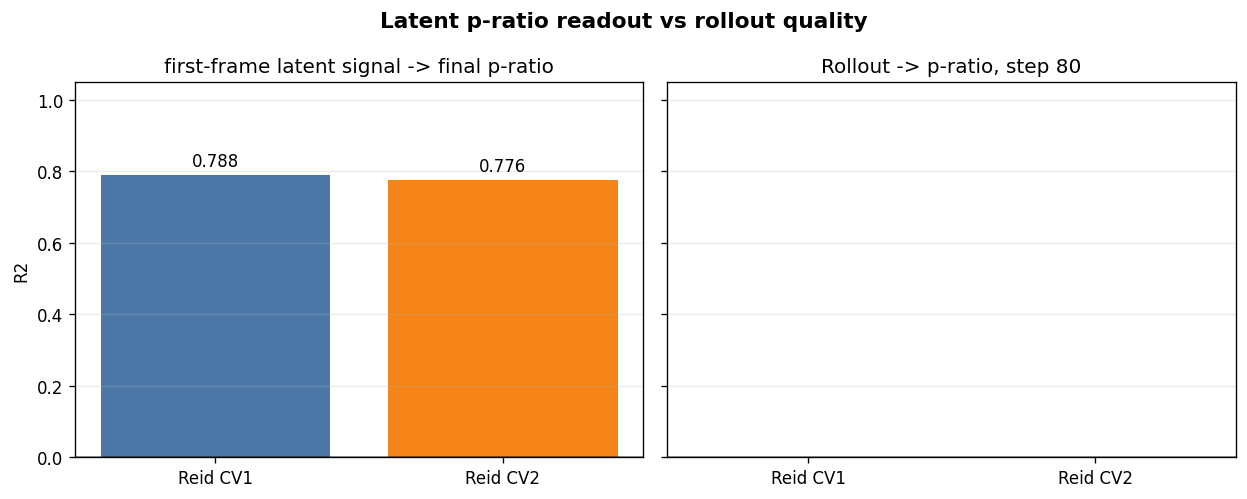

In [ ]:
# Side-by-side R2 summary: CV-to-p-ratio vs rollout
summary_rollout_steps = decoded_eval_steps if 'decoded_eval_steps' in globals() else int(rollout_stats_df['rollout_steps'].max())


def _linear_r2(y, X):
    y = np.asarray(y, dtype=float).reshape(-1)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    valid = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[valid]
    X = X[valid]
    if len(y) < X.shape[1] + 2 or np.isclose(np.std(y), 0.0):
        return float('nan')
    X_design = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(X_design, y, rcond=None)
    pred = X_design @ coef
    ss_res = float(np.sum((y - pred) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')


summary_rows = []
for dataset, group in trajectory_mean_df.groupby('dataset', sort=False):
    best_row = best_p_ratio_signal_df[best_p_ratio_signal_df['dataset'] == dataset] if 'best_p_ratio_signal_df' in globals() else pd.DataFrame()
    p_ratio_signal = best_row['signal'].iloc[0] if not best_row.empty else 'initial_z0'
    p_ratio_signal_source = best_row['source'].iloc[0] if not best_row.empty else 'single_latent'
    cv_cols = [p_ratio_signal] if p_ratio_signal in group.columns else []
    cv_to_pratio_r2 = _linear_r2(group['final_p_ratio'], group[cv_cols].to_numpy(dtype=float)) if cv_cols else float('nan')

    rollout_match = rollout_stats_df[
        (rollout_stats_df['dataset'] == dataset)
        & (rollout_stats_df['split'] == 'test')
        & (rollout_stats_df['rollout_steps'] == summary_rollout_steps)
    ]
    if rollout_match.empty:
        rollout_match = rollout_stats_df[
            (rollout_stats_df['dataset'] == dataset)
            & (rollout_stats_df['split'] == 'test')
        ].sort_values('rollout_steps').tail(1)
    rollout_r2 = float(rollout_match['p_ratio_r2'].iloc[0]) if not rollout_match.empty else float('nan')
    rollout_step = int(rollout_match['rollout_steps'].iloc[0]) if not rollout_match.empty else summary_rollout_steps

    summary_rows.append({
        'dataset': dataset,
        'p_ratio_signal': p_ratio_signal,
        'p_ratio_signal_source': p_ratio_signal_source,
        'cv_to_final_p_ratio_r2': cv_to_pratio_r2,
        'test_rollout_p_ratio_r2': rollout_r2,
        'rollout_steps': rollout_step,
    })

r2_summary_df = pd.DataFrame(summary_rows)
display(r2_summary_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
bar_palette = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
bar_colors = [bar_palette[i % len(bar_palette)] for i in range(len(r2_summary_df))]
labels = r2_summary_df['dataset'].str.replace('dePablo ', '', regex=False)

axes[0].bar(labels, r2_summary_df['cv_to_final_p_ratio_r2'], color=bar_colors)
axes[0].set_title('first-frame latent signal -> final p-ratio')
axes[0].set_ylabel('R2')
axes[0].set_ylim(0, 1.05)

axes[1].bar(labels, r2_summary_df['test_rollout_p_ratio_r2'], color=bar_colors)
axes[1].set_title(f'Rollout -> p-ratio, step {int(r2_summary_df["rollout_steps"].max())}')
axes[1].set_ylim(0, 1.05)

for ax in axes:
    ax.axhline(0, color='black', lw=1, alpha=0.45)
    ax.grid(axis='y', alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

fig.suptitle('Latent p-ratio readout vs rollout quality', fontsize=13, fontweight='bold')
plt.tight_layout()



## Current-Run Stiffness Mechanism And Ablation


,dataset,relationship,pearson_r,r2,n
3,Reid CV1,initial_z0 -> node_stiffness_mean,-0.9873,0.9748,72
19,Reid CV1,initial_z_linear_p_ratio -> node_stiffness_mean,-0.9873,0.9748,72
1,Reid CV1,initial_z0 -> stiffness_mean,-0.9872,0.9747,72
17,Reid CV1,initial_z_linear_p_ratio -> stiffness_mean,-0.9872,0.9747,72
4,Reid CV1,initial_z0 -> node_stiffness_std,-0.9489,0.9003,72
20,Reid CV1,initial_z_linear_p_ratio -> node_stiffness_std,-0.9489,0.9003,72
2,Reid CV1,initial_z0 -> stiffness_std,-0.9461,0.8951,72
18,Reid CV1,initial_z_linear_p_ratio -> stiffness_std,-0.9461,0.8951,72
25,Reid CV1,stiffness_std -> final_p_ratio,-0.9448,0.8927,72
5,Reid CV1,initial_z0 -> horizontal_stiffness,-0.9413,0.8860,72


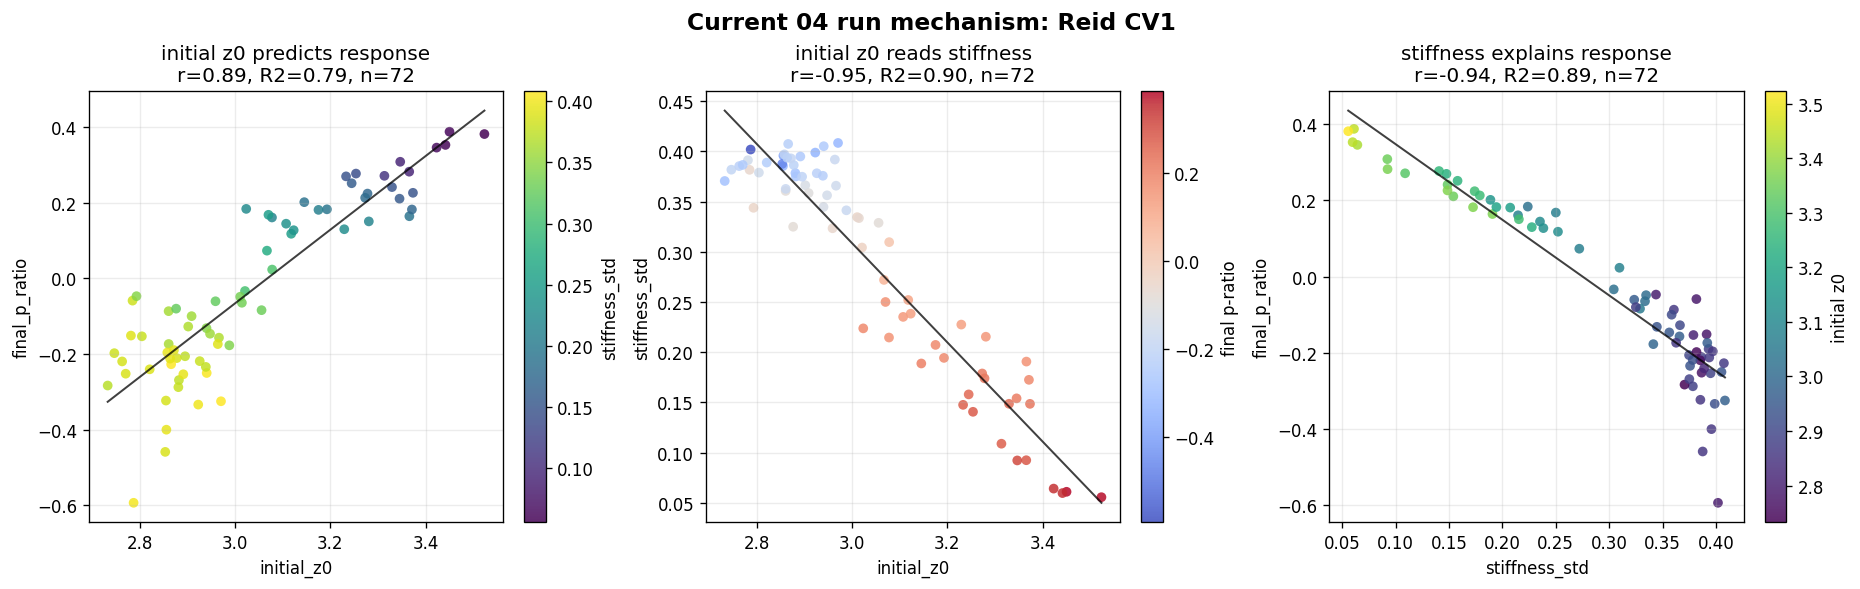

Saved figure to results/latent_space_simulator/analysis_exports/current_run_stiffness_mechanism.png


,dataset,latent,condition,pearson_r_to_final_p_ratio,r2_to_final_p_ratio,n
0,Reid CV1,z0,normal,0.8880,0.7885,72
1,Reid CV1,z0,masked,0.2629,0.0691,72
2,Reid CV1,z1,normal,NaN,NaN,0
3,Reid CV1,z1,masked,NaN,NaN,0
4,Reid CV2,z0,normal,-0.8846,0.7826,72
5,Reid CV2,z0,masked,0.1551,0.0241,72
6,Reid CV2,z1,normal,0.8849,0.7831,72
7,Reid CV2,z1,masked,-0.1286,0.0165,72


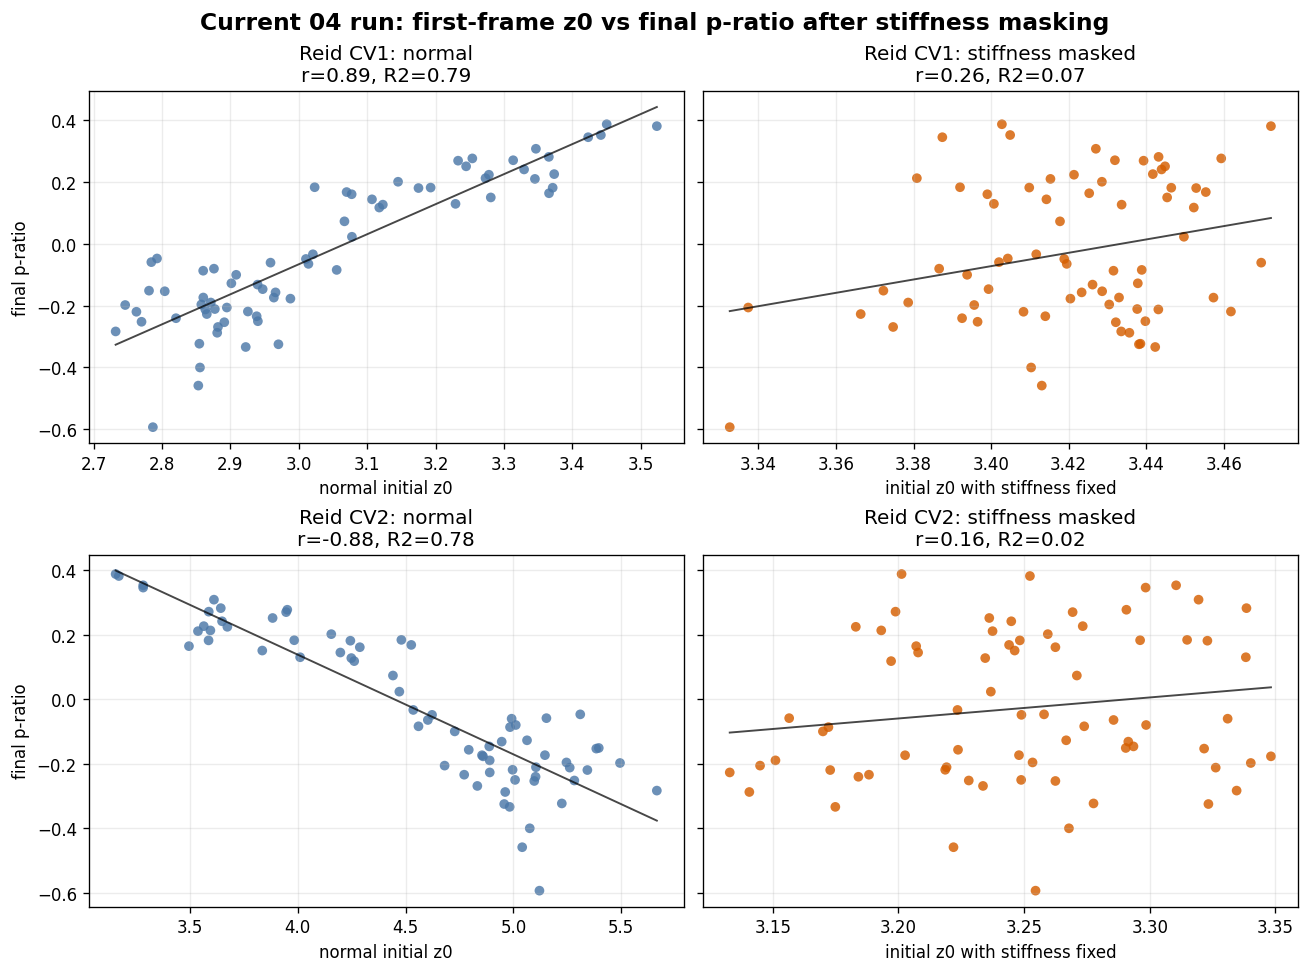

Saved scatter figure to results/latent_space_simulator/analysis_exports/current_run_stiffness_ablation_scatter_by_cv.png


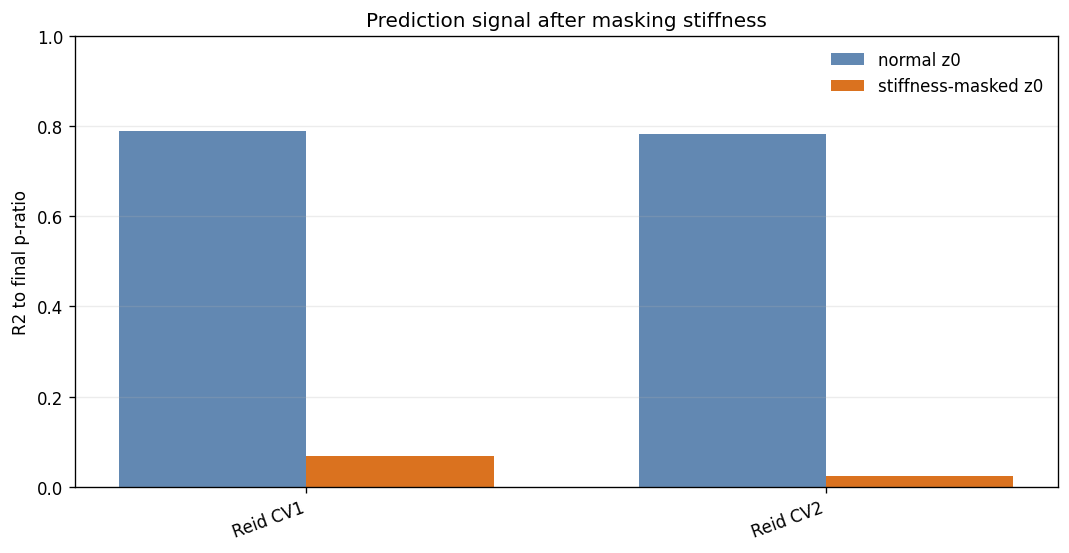

Saved bar figure to results/latent_space_simulator/analysis_exports/current_run_stiffness_ablation_r2_bar.png


In [ ]:
# Live mechanism check from the current 04 run. No saved 06 CSVs are read here.
def _unique_initial_edges_current(graph):
    pos = graph.x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_attr = graph.edge_attr.detach().cpu().float().numpy()
    pair_rows = {}
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        if i == j:
            continue
        key = (i, j) if i < j else (j, i)
        if key in pair_rows:
            continue
        vec = pos[j] - pos[i]
        length = float(np.linalg.norm(vec))
        stiffness = float(edge_attr[e, -1]) if edge_attr.size else np.nan
        pair_rows[key] = {'i': key[0], 'j': key[1], 'vec': vec, 'length': length, 'stiffness': stiffness}
    return list(pair_rows.values())


def _safe_mean(arr):
    arr = np.asarray(arr, dtype=float)
    return float(np.nanmean(arr)) if arr.size and np.isfinite(arr).any() else np.nan


def _safe_std(arr):
    arr = np.asarray(arr, dtype=float)
    return float(np.nanstd(arr)) if arr.size and np.isfinite(arr).any() else np.nan


def _summarize_initial_geometry_current(result, sim, sim_idx):
    graph = sim[0]
    n = int(graph.x.size(0))
    edges = _unique_initial_edges_current(graph)
    degree = np.zeros(n, dtype=float)
    stiffness = []
    node_stiffness_sum = np.zeros(n, dtype=float)
    horizontal_stiffness = []
    vertical_stiffness = []
    diagonal_stiffness = []
    for edge in edges:
        i, j = edge['i'], edge['j']
        degree[i] += 1
        degree[j] += 1
        node_stiffness_sum[i] += edge['stiffness']
        node_stiffness_sum[j] += edge['stiffness']
        stiffness.append(edge['stiffness'])
        length = edge['length']
        if length > 1e-12:
            unit = edge['vec'] / length
            if abs(float(unit[0])) >= 0.85:
                horizontal_stiffness.append(edge['stiffness'])
            elif abs(float(unit[1])) >= 0.85:
                vertical_stiffness.append(edge['stiffness'])
            else:
                diagonal_stiffness.append(edge['stiffness'])
    stiffness = np.asarray(stiffness, dtype=float)
    zero_stiffness_edge_count = int(np.isclose(stiffness, 0.0, atol=1e-12).sum()) if stiffness.size else 0
    zero_stiffness_edge_fraction = float(zero_stiffness_edge_count / stiffness.size) if stiffness.size else np.nan
    node_stiffness = np.divide(node_stiffness_sum, degree, out=np.full_like(node_stiffness_sum, np.nan), where=degree > 0)
    return {
        'dataset': result['label'],
        'latent_dim': int(result['params']['latent_dim']),
        'sim_idx': int(sim_idx),
        'edge_count': int(len(edges)),
        'zero_stiffness_edge_count': zero_stiffness_edge_count,
        'zero_stiffness_edge_fraction': zero_stiffness_edge_fraction,
        'stiffness_mean': _safe_mean(stiffness),
        'stiffness_std': _safe_std(stiffness),
        'node_stiffness_mean': _safe_mean(node_stiffness),
        'node_stiffness_std': _safe_std(node_stiffness),
        'horizontal_stiffness': _safe_mean(horizontal_stiffness),
        'vertical_stiffness': _safe_mean(vertical_stiffness),
        'diagonal_stiffness': _safe_mean(diagonal_stiffness),
    }


current_descriptor_rows = []
for result in source_results:
    for sim_idx, sim in enumerate(result['test_data']):
        current_descriptor_rows.append(_summarize_initial_geometry_current(result, sim, sim_idx))
current_initial_descriptor_df = pd.DataFrame(current_descriptor_rows)

trajectory_current_df = trajectory_mean_df.copy()
if 'latent_dim' not in trajectory_current_df.columns:
    dataset_to_latent_dim = {result['label']: int(result['params']['latent_dim']) for result in source_results}
    trajectory_current_df['latent_dim'] = trajectory_current_df['dataset'].map(dataset_to_latent_dim)
if 'latent_dim' not in current_initial_descriptor_df.columns:
    dataset_to_latent_dim = {result['label']: int(result['params']['latent_dim']) for result in source_results}
    current_initial_descriptor_df['latent_dim'] = current_initial_descriptor_df['dataset'].map(dataset_to_latent_dim)

current_bridge_df = trajectory_current_df.merge(
    current_initial_descriptor_df,
    on=['dataset', 'latent_dim', 'sim_idx'],
    how='left',
)

preferred_stiffness = [
    'stiffness_mean',
    'stiffness_std',
    'zero_stiffness_edge_count',
    'zero_stiffness_edge_fraction',
    'node_stiffness_mean',
    'node_stiffness_std',
    'horizontal_stiffness',
    'vertical_stiffness',
    'diagonal_stiffness',
]
current_stiffness_corr_rows = []
for dataset, group in current_bridge_df.groupby('dataset', sort=False):
    latent_cols_for_dataset = [col for col in group.columns if col.startswith('initial_z')]
    descriptor_cols_for_dataset = [col for col in preferred_stiffness if col in group.columns and group[col].nunique(dropna=True) > 1]
    for latent_col in latent_cols_for_dataset:
        pair = group[[latent_col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
        r = pearson_r(pair[latent_col], pair['final_p_ratio']) if len(pair) >= 3 else float('nan')
        current_stiffness_corr_rows.append({
            'dataset': dataset,
            'relationship': f'{latent_col} -> final_p_ratio',
            'pearson_r': r,
            'r2': r * r if np.isfinite(r) else float('nan'),
            'n': int(len(pair)),
        })
        for descriptor in descriptor_cols_for_dataset:
            pair = group[[latent_col, descriptor]].replace([np.inf, -np.inf], np.nan).dropna()
            r = pearson_r(pair[latent_col], pair[descriptor]) if len(pair) >= 3 else float('nan')
            current_stiffness_corr_rows.append({
                'dataset': dataset,
                'relationship': f'{latent_col} -> {descriptor}',
                'pearson_r': r,
                'r2': r * r if np.isfinite(r) else float('nan'),
                'n': int(len(pair)),
            })
    for descriptor in descriptor_cols_for_dataset:
        pair = group[[descriptor, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
        r = pearson_r(pair[descriptor], pair['final_p_ratio']) if len(pair) >= 3 else float('nan')
        current_stiffness_corr_rows.append({
            'dataset': dataset,
            'relationship': f'{descriptor} -> final_p_ratio',
            'pearson_r': r,
            'r2': r * r if np.isfinite(r) else float('nan'),
            'n': int(len(pair)),
        })
current_latent_stiffness_bridge_df = pd.DataFrame(current_stiffness_corr_rows)
display(current_latent_stiffness_bridge_df.assign(abs_r=lambda df: df['pearson_r'].abs()).sort_values(['dataset', 'abs_r'], ascending=[True, False]).drop(columns='abs_r').head(18).round(4))

# Shareable mechanism figure for the first current dataset, usually Reid CV1.
plot_dataset = source_results[0]['label'] if source_results else current_bridge_df['dataset'].iloc[0]
plot_df = current_bridge_df[current_bridge_df['dataset'].eq(plot_dataset)].copy()
if plot_df.empty or 'initial_z0' not in plot_df.columns:
    print('Need current_bridge_df with initial_z0 to plot current-run mechanism.')
else:
    descriptor_scores = []
    for descriptor in preferred_stiffness:
        if descriptor not in plot_df.columns or plot_df[descriptor].nunique(dropna=True) <= 1:
            continue
        rz = safe_corr(plot_df['initial_z0'], plot_df[descriptor])
        rp = safe_corr(plot_df[descriptor], plot_df['final_p_ratio'])
        descriptor_scores.append({'descriptor': descriptor, 'r_z0': rz, 'r_p_ratio': rp, 'score': abs(rz) + abs(rp)})
    current_descriptor_rank_df = pd.DataFrame(descriptor_scores).sort_values('score', ascending=False)
    if current_descriptor_rank_df.empty:
        print('No varying stiffness descriptor available for mechanism plot.')
    else:
        stiffness_col = current_descriptor_rank_df['descriptor'].iloc[0]

        def _pair_corr(df, x, y):
            pair = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
            r = pearson_r(pair[x], pair[y]) if len(pair) >= 3 else float('nan')
            return pair, r, r * r if np.isfinite(r) else float('nan')

        def _scatter_with_fit(ax, df, x, y, *, color=None, cmap='coolwarm', title=''):
            cols = [x, y] + ([color] if color else [])
            pair = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
            if color:
                sc = ax.scatter(pair[x], pair[y], c=pair[color], cmap=cmap, s=34, alpha=0.84, edgecolor='none')
            else:
                sc = ax.scatter(pair[x], pair[y], color='#4C78A8', s=34, alpha=0.84, edgecolor='none')
            if len(pair) >= 2:
                coef = np.polyfit(pair[x], pair[y], deg=1)
                xs = np.linspace(float(pair[x].min()), float(pair[x].max()), 120)
                ax.plot(xs, coef[0] * xs + coef[1], color='black', lw=1.2, alpha=0.75)
            r = pearson_r(pair[x], pair[y]) if len(pair) >= 3 else float('nan')
            r2 = r * r if np.isfinite(r) else float('nan')
            ax.set_title(f'{title}\nr={r:.2f}, R2={r2:.2f}, n={len(pair)}')
            ax.set_xlabel(x)
            ax.set_ylabel(y)
            ax.grid(alpha=0.24)
            return sc

        fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.8), constrained_layout=True)
        sc = _scatter_with_fit(axes[0], plot_df, 'initial_z0', 'final_p_ratio', color=stiffness_col, cmap='viridis', title='initial z0 predicts response')
        fig.colorbar(sc, ax=axes[0], label=stiffness_col)
        sc = _scatter_with_fit(axes[1], plot_df, 'initial_z0', stiffness_col, color='final_p_ratio', cmap='coolwarm', title='initial z0 reads stiffness')
        fig.colorbar(sc, ax=axes[1], label='final p-ratio')
        sc = _scatter_with_fit(axes[2], plot_df, stiffness_col, 'final_p_ratio', color='initial_z0', cmap='viridis', title='stiffness explains response')
        fig.colorbar(sc, ax=axes[2], label='initial z0')
        fig.suptitle(f'Current 04 run mechanism: {plot_dataset}', fontsize=14, fontweight='bold')
        current_mechanism_fig_path = run_dir / 'analysis_exports' / 'current_run_stiffness_mechanism.png'
        current_mechanism_fig_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(current_mechanism_fig_path, dpi=220, bbox_inches='tight')
        plt.show()
        print(f'Saved figure to {current_mechanism_fig_path}')

# Live stiffness ablation on the current 04 trained models.
def encode_frame_with_stiffness_mask_current(result, sim, t, *, device):
    use_result_stats(result)
    ref_graph = sim[0]
    cur_graph = sim[int(t)]
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
    node_feature = frame_node_feature(sim, t, mode=node_feature_mode, device=device)
    node_feature_norm = normalize_node_feature(node_feature)
    edge_raw = edge_features(ref_graph, cur_graph, device=device).clone()
    ref_edge_raw = edge_features(ref_graph, ref_graph, device=device).clone()
    explicit_stiffness_col = 2 * cfg['pos_dim'] + 4
    cur_edge_stiffness_col = edge_raw.shape[1] - 1
    explicit_value = edge_mean[0, explicit_stiffness_col]
    cur_value = edge_mean[0, cur_edge_stiffness_col]
    for raw in (edge_raw, ref_edge_raw):
        raw[:, explicit_stiffness_col] = explicit_value
        raw[:, cur_edge_stiffness_col] = cur_value
    edge_attr_norm = normalize_edge_attr(edge_raw)
    ref_edge_attr_norm = normalize_edge_attr(ref_edge_raw)
    edge_index = ref_graph.edge_index.to(device).long()
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    z, _ = result['ae'].encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
    return z.squeeze(0)

current_stiffness_ablation_rows = []
with torch.no_grad():
    for result in source_results:
        use_result_stats(result)
        for sim_idx, sim in enumerate(result['test_data']):
            z_normal = encode_frame(result['ae'], sim, 0, device=device).detach().cpu().numpy().reshape(-1)
            z_masked = encode_frame_with_stiffness_mask_current(result, sim, 0, device=device).detach().cpu().numpy().reshape(-1)
            row = {
                'dataset': result['label'],
                'latent_dim': int(result['params']['latent_dim']),
                'sim_idx': int(sim_idx),
                'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
            }
            for dim_idx, value in enumerate(z_normal):
                row[f'normal_z{dim_idx}'] = float(value)
            for dim_idx, value in enumerate(z_masked):
                row[f'masked_z{dim_idx}'] = float(value)
                row[f'delta_z{dim_idx}'] = float(value - z_normal[dim_idx])
            current_stiffness_ablation_rows.append(row)
current_stiffness_ablation_df = pd.DataFrame(current_stiffness_ablation_rows)

current_stiffness_ablation_corr_rows = []
for dataset, group in current_stiffness_ablation_df.groupby('dataset', sort=False):
    latent_dims = sorted(int(col.replace('normal_z', '')) for col in group.columns if col.startswith('normal_z'))
    for dim_idx in latent_dims:
        for condition in ['normal', 'masked']:
            signal = f'{condition}_z{dim_idx}'
            pair = group[[signal, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
            r = pearson_r(pair[signal], pair['final_p_ratio']) if len(pair) >= 3 else float('nan')
            current_stiffness_ablation_corr_rows.append({
                'dataset': dataset,
                'latent': f'z{dim_idx}',
                'condition': condition,
                'pearson_r_to_final_p_ratio': r,
                'r2_to_final_p_ratio': r * r if np.isfinite(r) else float('nan'),
                'n': int(len(pair)),
            })
current_stiffness_ablation_corr_df = pd.DataFrame(current_stiffness_ablation_corr_rows)
display(current_stiffness_ablation_corr_df.round(4))

z0_ablation = current_stiffness_ablation_corr_df[current_stiffness_ablation_corr_df['latent'].eq('z0')]
if not z0_ablation.empty:
    scatter_groups = list(current_stiffness_ablation_df.groupby('dataset', sort=False))
    fig, axes = plt.subplots(
        len(scatter_groups),
        2,
        figsize=(10.8, 4.0 * len(scatter_groups)),
        sharey='row',
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(len(scatter_groups), 2)

    for row_idx, (dataset, plot_ablation_df) in enumerate(scatter_groups):
        for col_idx, (condition, color, x_col, x_label) in enumerate([
            ('normal', '#4C78A8', 'normal_z0', 'normal initial z0'),
            ('stiffness masked', '#D55E00', 'masked_z0', 'initial z0 with stiffness fixed'),
        ]):
            ax = axes[row_idx, col_idx]
            plot_df = plot_ablation_df[[x_col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
            r = pearson_r(plot_df[x_col], plot_df['final_p_ratio']) if len(plot_df) >= 3 else float('nan')
            r2 = r * r if np.isfinite(r) else float('nan')
            ax.scatter(plot_df[x_col], plot_df['final_p_ratio'], s=34, alpha=0.82, color=color, edgecolor='none')
            if len(plot_df) >= 2:
                coef = np.polyfit(plot_df[x_col], plot_df['final_p_ratio'], deg=1)
                xs = np.linspace(float(plot_df[x_col].min()), float(plot_df[x_col].max()), 120)
                ax.plot(xs, coef[0] * xs + coef[1], color='black', lw=1.15, alpha=0.72)
            ax.set_title(f'{dataset}: {condition}\nr={r:.2f}, R2={r2:.2f}')
            ax.set_xlabel(x_label)
            if col_idx == 0:
                ax.set_ylabel('final p-ratio')
            ax.grid(alpha=0.24)

    fig.suptitle('Current 04 run: first-frame z0 vs final p-ratio after stiffness masking', fontsize=14, fontweight='bold')
    current_ablation_scatter_fig_path = run_dir / 'analysis_exports' / 'current_run_stiffness_ablation_scatter_by_cv.png'
    current_ablation_scatter_fig_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(current_ablation_scatter_fig_path, dpi=220, bbox_inches='tight')
    plt.show()
    print(f'Saved scatter figure to {current_ablation_scatter_fig_path}')

    bar_df = z0_ablation.pivot(index='dataset', columns='condition', values='r2_to_final_p_ratio').reindex(columns=['normal', 'masked'])
    fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.5), constrained_layout=True)
    x = np.arange(len(bar_df.index))
    width = 0.36
    ax.bar(x - width / 2, bar_df['normal'], width=width, label='normal z0', color='#4C78A8', alpha=0.88)
    ax.bar(x + width / 2, bar_df['masked'], width=width, label='stiffness-masked z0', color='#D55E00', alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_df.index, rotation=20, ha='right')
    ax.set_ylabel('R2 to final p-ratio')
    ymax = float(np.nanmax(bar_df.to_numpy())) if np.isfinite(bar_df.to_numpy()).any() else 1.0
    ax.set_ylim(0, max(1.0, ymax * 1.12))
    ax.set_title('Prediction signal after masking stiffness')
    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.24)

    current_ablation_bar_fig_path = run_dir / 'analysis_exports' / 'current_run_stiffness_ablation_r2_bar.png'
    current_ablation_bar_fig_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(current_ablation_bar_fig_path, dpi=220, bbox_inches='tight')
    plt.show()
    print(f'Saved bar figure to {current_ablation_bar_fig_path}')



## Displacement-Stiffness Bridge

Check whether the displacement/strain response itself carries the stiffness signal that the latent readout uses.


,dataset,source,target,pearson_r,r2,n
76,Reid CV1,node_stiffness_mean,initial_z0,-0.9873,0.9748,72
77,Reid CV1,node_stiffness_mean,initial_z_linear_p_ratio,-0.9873,0.9748,72
24,Reid CV1,stiffness_mean,initial_z0,-0.9872,0.9747,72
25,Reid CV1,stiffness_mean,initial_z_linear_p_ratio,-0.9872,0.9747,72
1,Reid CV1,stiffness_std,early_y_strain,-0.9680,0.9369,72
63,Reid CV1,node_stiffness_std,initial_z0,-0.9489,0.9003,72
64,Reid CV1,node_stiffness_std,initial_z_linear_p_ratio,-0.9489,0.9003,72
11,Reid CV1,stiffness_std,initial_z0,-0.9461,0.8951,72
12,Reid CV1,stiffness_std,initial_z_linear_p_ratio,-0.9461,0.8951,72
10,Reid CV1,stiffness_std,final_p_ratio,-0.9448,0.8927,72


target                         early_disp_anisotropy  early_mean_abs_dx  \
dataset  source                                                           
Reid CV1 horizontal_stiffness                  0.657             -0.186   
         node_stiffness_mean                   0.630             -0.227   
         node_stiffness_std                    0.636             -0.244   
         stiffness_mean                        0.626             -0.229   
         stiffness_std                         0.652             -0.218   
         vertical_stiffness                    0.653             -0.161   
Reid CV2 horizontal_stiffness                  0.657             -0.186   
         node_stiffness_mean                   0.630             -0.227   
         node_stiffness_std                    0.636             -0.244   
         stiffness_mean                        0.626             -0.229   
         stiffness_std                         0.652             -0.218   
         vertical_stiffness                    0.653             -0.161   

target                         early_mean_abs_dy  early_x_strain  \
dataset  source                                                    
Reid CV1 horizontal_stiffness             -0.792          -0.108   
         node_stiffness_mean              -0.814          -0.049   
         node_stiffness_std               -0.817          -0.020   
         stiffness_mean                   -0.812          -0.052   
         stiffness_std                    -0.858          -0.001   
         vertical_stiffness               -0.873          -0.006   
Reid CV2 horizontal_stiffness             -0.792          -0.108   
         node_stiffness_mean              -0.814          -0.049   
         node_stiffness_std               -0.817          -0.020   
         stiffness_mean                   -0.812          -0.052   
         stiffness_std                    -0.858          -0.001   
         vertical_stiffness               -0.873          -0.006   

target                         early_y_strain  final_disp_anisotropy  \
dataset  source                                                        
Reid CV1 horizontal_stiffness          -0.927                 -0.134   
         node_stiffness_mean           -0.903                 -0.108   
         node_stiffness_std            -0.930                 -0.140   
         stiffness_mean                -0.904                 -0.112   
         stiffness_std                 -0.968                 -0.078   
         vertical_stiffness            -0.885                  0.066   
Reid CV2 horizontal_stiffness          -0.927                 -0.134   
         node_stiffness_mean           -0.903                 -0.108   
         node_stiffness_std            -0.930                 -0.140   
         stiffness_mean                -0.904                 -0.112   
         stiffness_std                 -0.968                 -0.078   
         vertical_stiffness            -0.885                  0.066   

target                         final_mean_abs_dx  final_mean_abs_dy  \
dataset  source                                                       
Reid CV1 horizontal_stiffness              0.120              0.286   
         node_stiffness_mean               0.107              0.216   
         node_stiffness_std                0.095              0.247   
         stiffness_mean                    0.106              0.220   
         stiffness_std                     0.108              0.200   
         vertical_stiffness                0.114              0.030   
Reid CV2 horizontal_stiffness              0.120              0.286   
         node_stiffness_mean               0.107              0.216   
         node_stiffness_std                0.095              0.247   
         stiffness_mean                    0.106              0.220   
         stiffness_std                     0.108              0.200   
         vertical_stiffness                0.114              0.

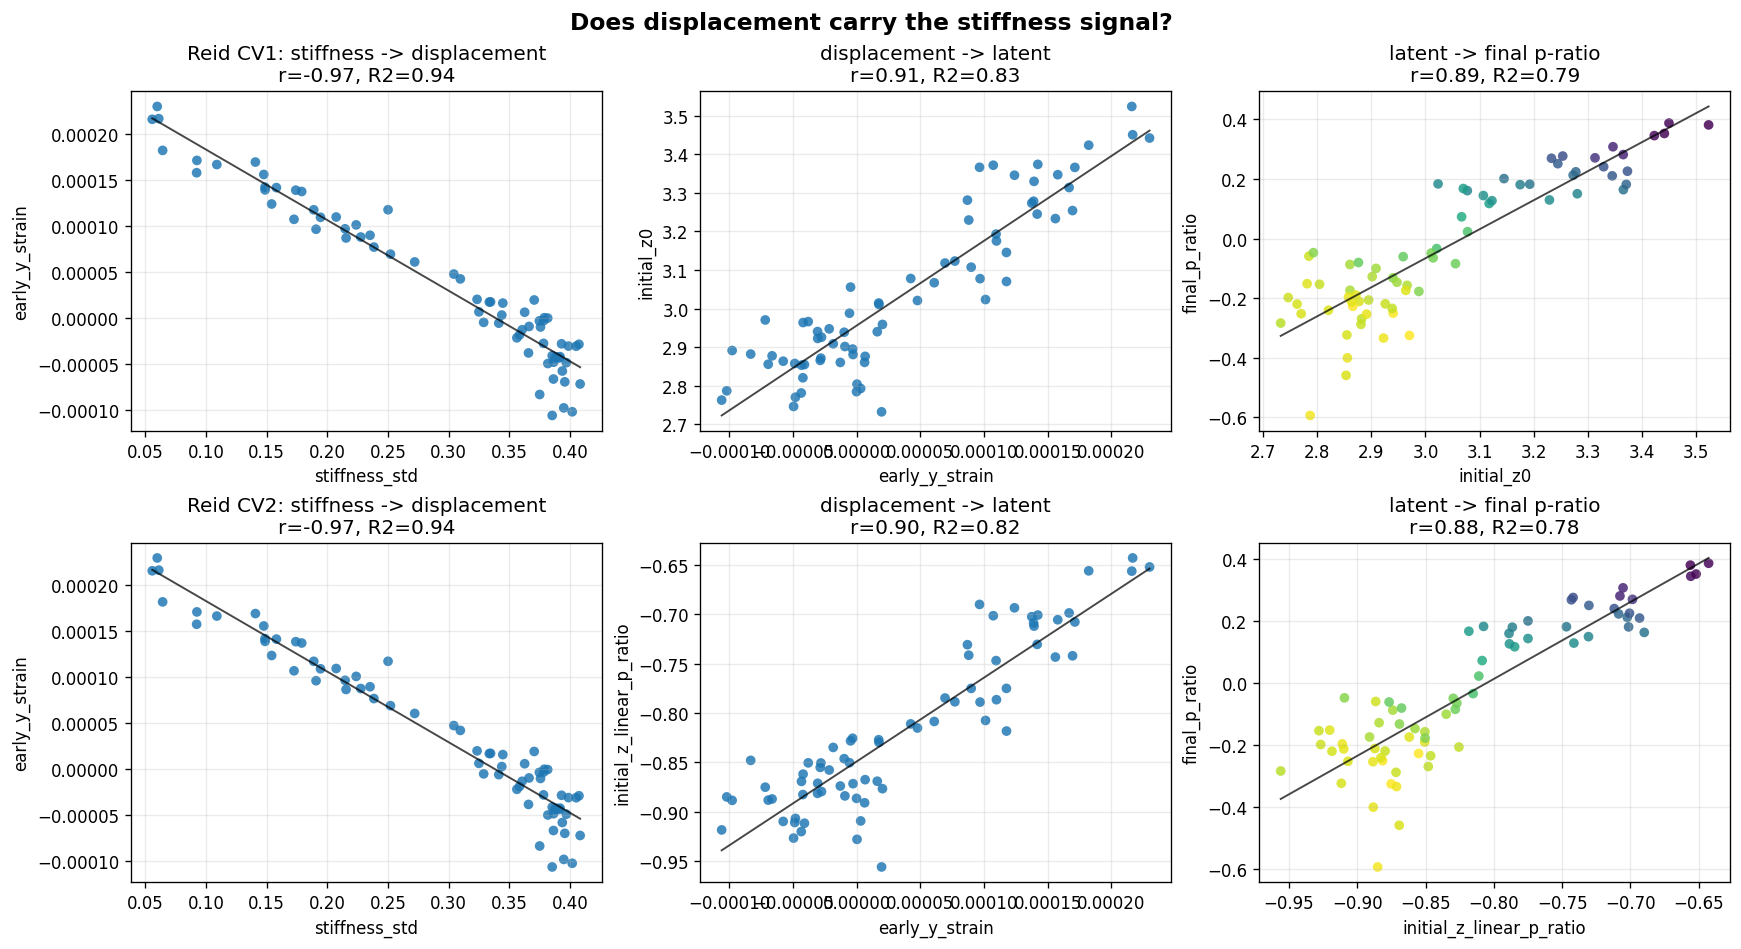

In [ ]:
# Does the displacement response itself correlate with initial stiffness?
# This uses only the current 04 run and the current test split.
def _box_strain_descriptor(sim, filtered_step):
    ref = sim[0].x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    frame_idx = frame_for_filtered_step(sim, filtered_step)
    cur = sim[frame_idx].x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    disp = cur - ref
    ref_span = np.ptp(ref, axis=0)
    cur_span = np.ptp(cur, axis=0)
    ref_span = np.where(np.abs(ref_span) < 1e-12, np.nan, ref_span)
    strain = (cur_span - ref_span) / ref_span
    mean_abs_dx = float(np.nanmean(np.abs(disp[:, 0]))) if disp.shape[1] >= 1 else np.nan
    mean_abs_dy = float(np.nanmean(np.abs(disp[:, 1]))) if disp.shape[1] >= 2 else np.nan
    return {
        'frame': int(frame_idx),
        'x_strain': float(strain[0]) if len(strain) >= 1 else np.nan,
        'y_strain': float(strain[1]) if len(strain) >= 2 else np.nan,
        'mean_abs_dx': mean_abs_dx,
        'mean_abs_dy': mean_abs_dy,
        'disp_anisotropy': float(mean_abs_dx / max(mean_abs_dy, 1e-12)) if np.isfinite(mean_abs_dx) and np.isfinite(mean_abs_dy) else np.nan,
    }


early_filtered_step = int(cfg.get('displacement_bridge_filtered_step', 2))
final_filtered_step = int(cfg.get('summary_rollout_step', 80))

displacement_rows = []
for result in source_results:
    for sim_idx, sim in enumerate(result['test_data']):
        early = _box_strain_descriptor(sim, early_filtered_step)
        final = _box_strain_descriptor(sim, final_filtered_step)
        row = {
            'dataset': result['label'],
            'latent_dim': int(result['params']['latent_dim']),
            'sim_idx': int(sim_idx),
            'early_filtered_step': early_filtered_step,
            'early_frame': early['frame'],
            'final_filtered_step': final_filtered_step,
            'final_frame': final['frame'],
            'early_x_strain': early['x_strain'],
            'early_y_strain': early['y_strain'],
            'early_mean_abs_dx': early['mean_abs_dx'],
            'early_mean_abs_dy': early['mean_abs_dy'],
            'early_disp_anisotropy': early['disp_anisotropy'],
            'final_x_strain': final['x_strain'],
            'final_y_strain': final['y_strain'],
            'final_mean_abs_dx': final['mean_abs_dx'],
            'final_mean_abs_dy': final['mean_abs_dy'],
            'final_disp_anisotropy': final['disp_anisotropy'],
            'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
        }
        displacement_rows.append(row)

displacement_stiffness_df = pd.DataFrame(displacement_rows)
if displacement_stiffness_df.empty:
    print('No displacement rows available. Run the training cell first.')
else:
    if 'current_initial_descriptor_df' in globals() and not current_initial_descriptor_df.empty:
        descriptor_keep = [
            col for col in [
                'dataset', 'latent_dim', 'sim_idx', 'stiffness_mean', 'stiffness_std',
                'zero_stiffness_edge_count', 'zero_stiffness_edge_fraction',
                'node_stiffness_mean', 'node_stiffness_std', 'horizontal_stiffness',
                'vertical_stiffness', 'diagonal_stiffness', 'edge_count'
            ] if col in current_initial_descriptor_df.columns
        ]
        displacement_stiffness_df = displacement_stiffness_df.merge(
            current_initial_descriptor_df[descriptor_keep],
            on=['dataset', 'latent_dim', 'sim_idx'],
            how='left',
        )

    if 'trajectory_mean_df' in globals() and not trajectory_mean_df.empty:
        latent_keep = [col for col in trajectory_mean_df.columns if col.startswith('initial_z')]
        if 'initial_z_linear_p_ratio' in trajectory_mean_df.columns:
            latent_keep.append('initial_z_linear_p_ratio')
        latent_keep = ['dataset', 'sim_idx'] + list(dict.fromkeys(latent_keep))
        displacement_stiffness_df = displacement_stiffness_df.merge(
            trajectory_mean_df[latent_keep],
            on=['dataset', 'sim_idx'],
            how='left',
        )

    stiffness_cols = [
        col for col in [
            'stiffness_std', 'stiffness_mean', 'zero_stiffness_edge_count', 'zero_stiffness_edge_fraction',
            'horizontal_stiffness', 'vertical_stiffness', 'node_stiffness_std', 'node_stiffness_mean'
        ] if col in displacement_stiffness_df.columns and displacement_stiffness_df[col].nunique(dropna=True) > 1
    ]
    displacement_cols = [
        'early_x_strain', 'early_y_strain', 'early_mean_abs_dx', 'early_mean_abs_dy', 'early_disp_anisotropy',
        'final_x_strain', 'final_y_strain', 'final_mean_abs_dx', 'final_mean_abs_dy', 'final_disp_anisotropy'
    ]
    target_cols = [col for col in displacement_cols + ['final_p_ratio', 'initial_z0', 'initial_z_linear_p_ratio'] if col in displacement_stiffness_df.columns]

    bridge_corr_rows = []
    for dataset, group in displacement_stiffness_df.groupby('dataset', sort=False):
        for source_col in stiffness_cols:
            for target_col in target_cols:
                pair = group[[source_col, target_col]].replace([np.inf, -np.inf], np.nan).dropna()
                r = pearson_r(pair[source_col], pair[target_col]) if len(pair) >= 3 else float('nan')
                bridge_corr_rows.append({
                    'dataset': dataset,
                    'source': source_col,
                    'target': target_col,
                    'pearson_r': r,
                    'abs_pearson_r': abs(r) if np.isfinite(r) else np.nan,
                    'r2': r * r if np.isfinite(r) else np.nan,
                    'n': int(len(pair)),
                })
    displacement_stiffness_corr_df = pd.DataFrame(bridge_corr_rows)
    display(
        displacement_stiffness_corr_df
        .sort_values(['dataset', 'abs_pearson_r'], ascending=[True, False])
        .head(18)
        .drop(columns='abs_pearson_r')
        .round(4)
    )

    heat_df = displacement_stiffness_corr_df.pivot_table(
        index=['dataset', 'source'], columns='target', values='pearson_r'
    )
    display(heat_df.round(3))

    def _bridge_scatter(ax, df, x, y, title, color=None):
        cols = [x, y] + ([color] if color else [])
        plot_df = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
        if plot_df.empty:
            ax.set_axis_off()
            return None
        if color:
            sc = ax.scatter(plot_df[x], plot_df[y], c=plot_df[color], cmap='viridis', s=34, alpha=0.84, edgecolor='none')
        else:
            sc = ax.scatter(plot_df[x], plot_df[y], s=34, alpha=0.84, edgecolor='none')
        if len(plot_df) >= 2 and plot_df[x].nunique() > 1:
            coef = np.polyfit(plot_df[x], plot_df[y], deg=1)
            xs = np.linspace(float(plot_df[x].min()), float(plot_df[x].max()), 100)
            ax.plot(xs, coef[0] * xs + coef[1], color='black', lw=1.15, alpha=0.72)
        r = pearson_r(plot_df[x], plot_df[y]) if len(plot_df) >= 3 else float('nan')
        ax.set_title(f'{title}\nr={r:.2f}, R2={r*r:.2f}' if np.isfinite(r) else title)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.grid(alpha=0.25)
        return sc

    plot_groups = list(displacement_stiffness_df.groupby('dataset', sort=False))
    fig, axes = plt.subplots(len(plot_groups), 3, figsize=(14.4, 3.9 * len(plot_groups)), squeeze=False, constrained_layout=True)
    for row_idx, (dataset, group) in enumerate(plot_groups):
        if 'stiffness_std' in group.columns:
            stiffness_signal = 'stiffness_std'
        elif stiffness_cols:
            stiffness_signal = stiffness_cols[0]
        else:
            continue
        candidate_disp = [col for col in displacement_cols if col in group.columns]
        if candidate_disp:
            disp_scores = []
            for col in candidate_disp:
                pair = group[[stiffness_signal, col]].replace([np.inf, -np.inf], np.nan).dropna()
                r = pearson_r(pair[stiffness_signal], pair[col]) if len(pair) >= 3 else float('nan')
                disp_scores.append((abs(r) if np.isfinite(r) else -np.inf, col))
            displacement_signal = sorted(disp_scores, reverse=True)[0][1]
        else:
            displacement_signal = 'final_y_strain'
        best_row = best_p_ratio_signal_df[best_p_ratio_signal_df['dataset'].eq(dataset)] if 'best_p_ratio_signal_df' in globals() and not best_p_ratio_signal_df.empty else pd.DataFrame()
        latent_signal = best_row['signal'].iloc[0] if not best_row.empty and best_row['signal'].iloc[0] in group.columns else 'initial_z0'

        _bridge_scatter(axes[row_idx, 0], group, stiffness_signal, displacement_signal, f'{dataset}: stiffness -> displacement')
        _bridge_scatter(axes[row_idx, 1], group, displacement_signal, latent_signal, 'displacement -> latent')
        _bridge_scatter(axes[row_idx, 2], group, latent_signal, 'final_p_ratio', 'latent -> final p-ratio', color=stiffness_signal)

    fig.suptitle('Does displacement carry the stiffness signal?', fontsize=14, fontweight='bold')
    plt.show()


## Systematic Latent Interpretability


,dataset,loo_ridge_r2,features,n
0,Reid CV1,0.901,"stiffness_mean, stiffness_std, node_stiffness_...",72
1,Reid CV2,0.901,"stiffness_mean, stiffness_std, node_stiffness_...",72


,dataset,latent,target,pearson_r,r2,n
3,Reid CV1,initial_z0,node_stiffness_mean,-0.9873,0.9748,72
1,Reid CV1,initial_z0,stiffness_mean,-0.9872,0.9747,72
4,Reid CV1,initial_z0,node_stiffness_std,-0.9489,0.9003,72
2,Reid CV1,initial_z0,stiffness_std,-0.9461,0.8951,72
5,Reid CV1,initial_z0,horizontal_stiffness,-0.9413,0.8860,72
9,Reid CV1,initial_z1,final_p_ratio,NaN,NaN,0
10,Reid CV1,initial_z1,stiffness_mean,NaN,NaN,0
11,Reid CV1,initial_z1,stiffness_std,NaN,NaN,0
12,Reid CV1,initial_z1,node_stiffness_mean,NaN,NaN,0
13,Reid CV1,initial_z1,node_stiffness_std,NaN,NaN,0


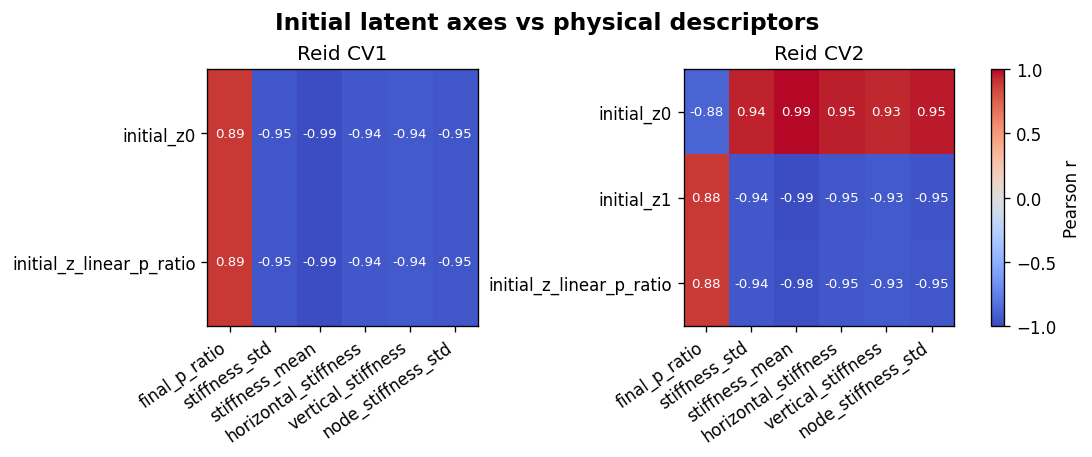

,dataset,variant,latent,pearson_r_to_final_p_ratio,r2_to_final_p_ratio,latent_std,n,normal_r2,r2_drop_vs_normal
0,Reid CV1,normal,z0,0.8880,0.7885,0.2107,72,0.7885,0.0000
1,Reid CV1,normal,z1,NaN,NaN,NaN,0,NaN,NaN
2,Reid CV1,stiffness_global_mean,z0,0.2629,0.0691,0.0281,72,0.7885,0.7193
3,Reid CV1,stiffness_global_mean,z1,NaN,NaN,NaN,0,NaN,NaN
4,Reid CV1,stiffness_network_mean,z0,0.8874,0.7874,0.2163,72,0.7885,0.0011
5,Reid CV1,stiffness_network_mean,z1,NaN,NaN,NaN,0,NaN,NaN
6,Reid CV1,edge_geometry_train_mean,z0,0.8898,0.7918,0.2095,72,0.7885,-0.0033
7,Reid CV1,edge_geometry_train_mean,z1,NaN,NaN,NaN,0,NaN,NaN
8,Reid CV1,zero_ref_pos,z0,0.8865,0.7859,0.2093,72,0.7885,0.0026
9,Reid CV1,zero_ref_pos,z1,NaN,NaN,NaN,0,NaN,NaN


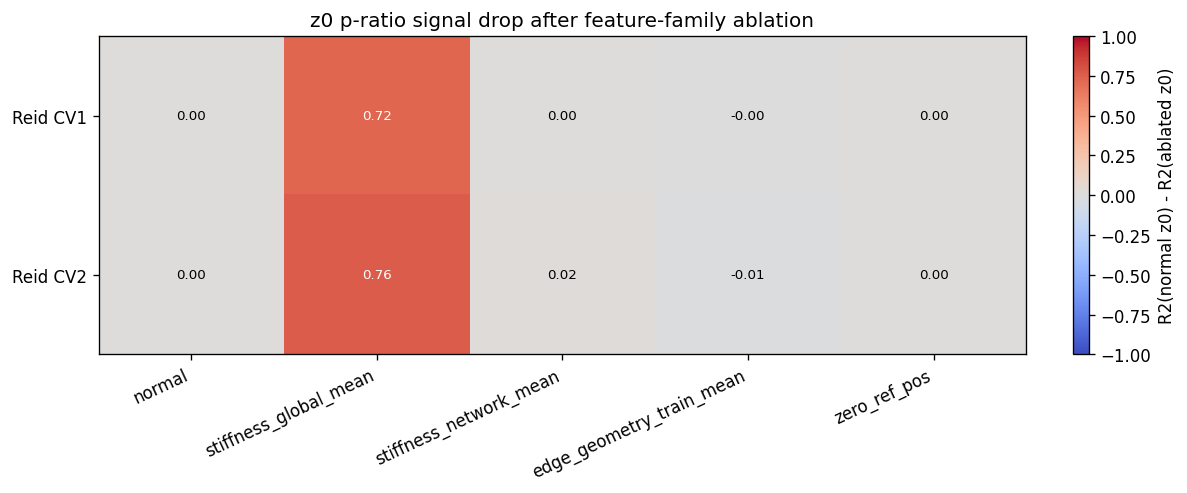

,sim_idx,edge_i,edge_j,stiffness,stiffness_percentile,stiffness_zscore_within_sim,contribution,abs_contribution,abs_contribution_percentile,final_p_ratio
340,2,11,23,0.32337,0.00580,-1.78115,0.00345,0.00345,1.00000,0.38738
298,2,3,4,0.34600,0.05507,-1.41057,0.00277,0.00277,0.99710,0.38738
597,2,101,102,0.56322,0.97971,2.14643,-0.00277,0.00277,0.99420,0.38738
304,2,4,5,0.35354,0.07826,-1.28709,0.00256,0.00256,0.99130,0.38738
500,2,67,68,0.54513,0.95072,1.85023,-0.00231,0.00231,0.98841,0.38738
290,2,1,2,0.54334,0.94493,1.82095,-0.00220,0.00220,0.98551,0.38738
453,2,50,51,0.62741,1.00000,3.19754,-0.00211,0.00211,0.98261,0.38738
315,2,6,7,0.37200,0.15652,-0.98484,0.00205,0.00205,0.97971,0.38738
80,42,21,22,1.09176,0.98233,1.18976,-0.01696,0.01696,1.00000,-0.59361
220,42,70,71,0.00095,0.17314,-1.51960,0.01636,0.01636,0.99647,-0.59361


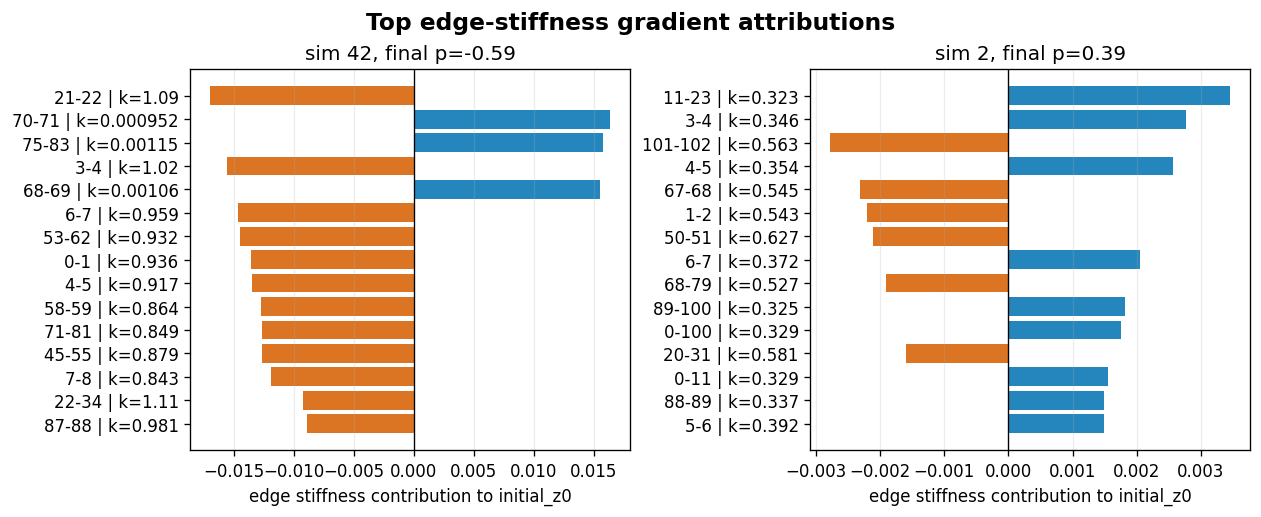

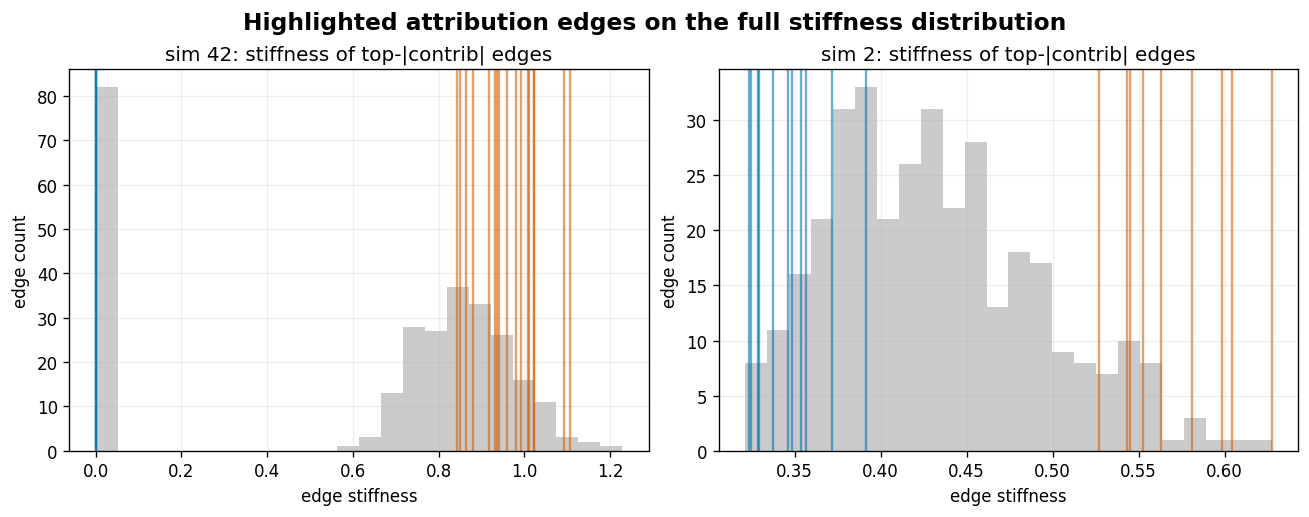

Saved stiffness distribution figure to results/latent_space_simulator/analysis_exports/systematic_edge_attribution_stiffness_distribution.png


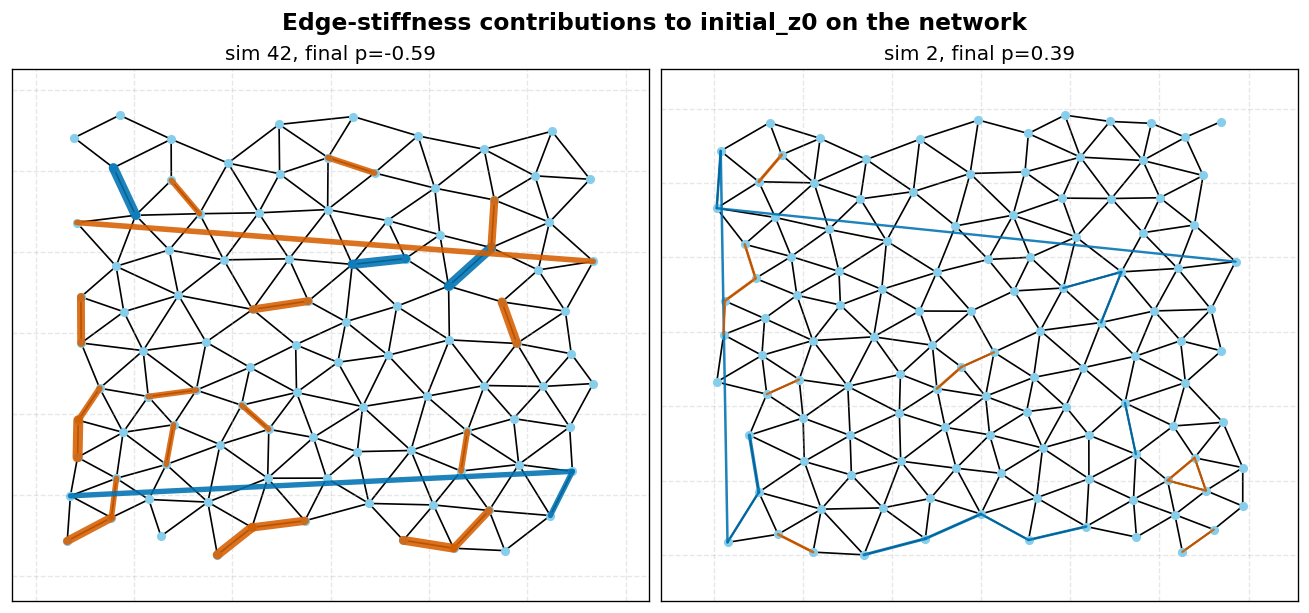

Saved graph attribution figure to results/latent_space_simulator/analysis_exports/systematic_edge_stiffness_attribution_graphs.png
Wrote systematic interpretability exports to results/latent_space_simulator/analysis_exports


In [ ]:
# Systematic current-run interpretation: descriptor baseline, latent decomposition,
# feature-family ablations, and edge-stiffness attribution. No saved 06 tables are used.
if 'current_bridge_df' not in globals() or current_bridge_df.empty:
    print('Run the Current-Run Stiffness Mechanism And Ablation cell first.')
else:
    descriptor_cols = [
        col for col in [
            'stiffness_mean', 'stiffness_std', 'zero_stiffness_edge_count', 'zero_stiffness_edge_fraction',
            'node_stiffness_mean', 'node_stiffness_std', 'horizontal_stiffness',
            'vertical_stiffness', 'diagonal_stiffness', 'edge_count'
        ]
        if col in current_bridge_df.columns and current_bridge_df[col].nunique(dropna=True) > 1
    ]

    def _loo_ridge_r2(df, feature_cols, target_col='final_p_ratio', lam=0.1):
        model_df = df[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(model_df) < len(feature_cols) + 3:
            return float('nan'), pd.DataFrame()
        X = model_df[feature_cols].to_numpy(dtype=float)
        y = model_df[target_col].to_numpy(dtype=float)
        mu = X.mean(axis=0, keepdims=True)
        sd = X.std(axis=0, keepdims=True)
        sd[sd == 0] = 1.0
        Xs = (X - mu) / sd
        preds = np.full(len(y), np.nan, dtype=float)
        penalty = np.diag([0.0] + [1.0] * Xs.shape[1])
        for i in range(len(y)):
            mask = np.ones(len(y), dtype=bool)
            mask[i] = False
            X_design = np.column_stack([np.ones(mask.sum()), Xs[mask]])
            beta = np.linalg.solve(X_design.T @ X_design + lam * penalty, X_design.T @ y[mask])
            preds[i] = np.r_[1.0, Xs[i]] @ beta
        ss_res = float(np.sum((y - preds) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')

        X_design = np.column_stack([np.ones(len(y)), Xs])
        beta = np.linalg.solve(X_design.T @ X_design + lam * penalty, X_design.T @ y)
        coef_df = pd.DataFrame({'feature': feature_cols, 'standardized_coef': beta[1:]})
        return r2, coef_df.sort_values('standardized_coef', key=lambda s: s.abs(), ascending=False)

    # 1) Descriptor-only baseline: how much p-ratio is already in initial stiffness/geometry?
    descriptor_baseline_rows = []
    descriptor_coef_frames = []
    for dataset, group in current_bridge_df.groupby('dataset', sort=False):
        usable_cols = [col for col in descriptor_cols if group[col].nunique(dropna=True) > 1]
        r2, coef_df = _loo_ridge_r2(group, usable_cols, lam=0.1) if usable_cols else (float('nan'), pd.DataFrame())
        descriptor_baseline_rows.append({
            'dataset': dataset,
            'loo_ridge_r2': r2,
            'features': ', '.join(usable_cols),
            'n': int(group[['final_p_ratio'] + usable_cols].dropna().shape[0]) if usable_cols else 0,
        })
        if not coef_df.empty:
            descriptor_coef_frames.append(coef_df.assign(dataset=dataset))
    descriptor_baseline_df = pd.DataFrame(descriptor_baseline_rows)
    descriptor_coef_df = pd.concat(descriptor_coef_frames, ignore_index=True) if descriptor_coef_frames else pd.DataFrame()
    display(descriptor_baseline_df.round(4))

    # 2) Latent-to-descriptor decomposition: what does each initial z axis look like?
    latent_descriptor_corr_rows = []
    for dataset, group in current_bridge_df.groupby('dataset', sort=False):
        latent_cols = [col for col in group.columns if col.startswith('initial_z')]
        for latent_col in latent_cols:
            pair = group[[latent_col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
            r = pearson_r(pair[latent_col], pair['final_p_ratio']) if len(pair) >= 3 else float('nan')
            latent_descriptor_corr_rows.append({
                'dataset': dataset, 'latent': latent_col, 'target': 'final_p_ratio',
                'pearson_r': r, 'r2': r * r if np.isfinite(r) else float('nan'), 'n': int(len(pair))
            })
            for descriptor in descriptor_cols:
                if descriptor not in group.columns or group[descriptor].nunique(dropna=True) <= 1:
                    continue
                pair = group[[latent_col, descriptor]].replace([np.inf, -np.inf], np.nan).dropna()
                r = pearson_r(pair[latent_col], pair[descriptor]) if len(pair) >= 3 else float('nan')
                latent_descriptor_corr_rows.append({
                    'dataset': dataset, 'latent': latent_col, 'target': descriptor,
                    'pearson_r': r, 'r2': r * r if np.isfinite(r) else float('nan'), 'n': int(len(pair))
                })
    latent_descriptor_corr_df = pd.DataFrame(latent_descriptor_corr_rows)
    display(
        latent_descriptor_corr_df.assign(abs_r=lambda df: df['pearson_r'].abs())
        .sort_values(['dataset', 'latent', 'abs_r'], ascending=[True, True, False])
        .drop(columns='abs_r')
        .groupby(['dataset', 'latent'], as_index=False)
        .head(5)
        .round(4)
    )

    heat_targets = ['final_p_ratio', 'stiffness_std', 'stiffness_mean', 'zero_stiffness_edge_count', 'zero_stiffness_edge_fraction', 'horizontal_stiffness', 'vertical_stiffness', 'node_stiffness_std']
    heat_targets = [target for target in heat_targets if target in set(latent_descriptor_corr_df['target'])]
    heat_rows = []
    for dataset, group in latent_descriptor_corr_df[latent_descriptor_corr_df['target'].isin(heat_targets)].groupby('dataset', sort=False):
        pivot = group.pivot_table(index='latent', columns='target', values='pearson_r')
        heat_rows.append((dataset, pivot.reindex(columns=heat_targets)))
    if heat_rows:
        fig, axes = plt.subplots(1, len(heat_rows), figsize=(4.5 * len(heat_rows), 3.7), constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, (dataset, pivot) in zip(axes, heat_rows):
            im = ax.imshow(pivot.fillna(0.0).to_numpy(), vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
            ax.set_title(dataset)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            for y in range(pivot.shape[0]):
                for x in range(pivot.shape[1]):
                    val = pivot.iloc[y, x]
                    if np.isfinite(val):
                        ax.text(x, y, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(val) > 0.55 else 'black')
        fig.colorbar(im, ax=axes.tolist(), label='Pearson r')
        fig.suptitle('Initial latent axes vs physical descriptors', fontsize=14, fontweight='bold')
        plt.show()

    # 3) Feature-family ablation matrix for first-frame latent readout.
    def _edge_feature_columns():
        explicit_stiffness_col = 2 * cfg['pos_dim'] + 4
        cur_edge_start = 2 * cfg['pos_dim'] + 5
        return {
            'ref_direction_length': list(range(0, cfg['pos_dim'])) + [2 * cfg['pos_dim']],
            'current_direction_length': list(range(cfg['pos_dim'], 2 * cfg['pos_dim'])) + [2 * cfg['pos_dim'] + 1],
            'stretch': [2 * cfg['pos_dim'] + 2, 2 * cfg['pos_dim'] + 3],
            'stiffness': [explicit_stiffness_col, cur_edge_start + cfg['pos_dim'] + 1],
            'raw_current_edge_geometry': list(range(cur_edge_start, cur_edge_start + cfg['pos_dim'] + 1)),
        }

    def encode_frame_feature_variant(result, sim, t, *, variant):
        use_result_stats(result)
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        if variant == 'zero_ref_pos':
            ref_pos_for_model = torch.zeros_like(ref_pos)
        else:
            ref_pos_for_model = ref_pos
        node_feature = frame_node_feature(sim, t, mode=node_feature_mode, device=device)
        node_feature_norm = normalize_node_feature(node_feature)
        edge_raw = edge_features(ref_graph, cur_graph, device=device).clone()
        ref_edge_raw = edge_features(ref_graph, ref_graph, device=device).clone()
        cols = _edge_feature_columns()

        def set_cols_to_train_mean(raw, selected_cols):
            for col in selected_cols:
                raw[:, col] = edge_mean[0, col]

        if variant == 'normal':
            pass
        elif variant == 'stiffness_global_mean':
            set_cols_to_train_mean(edge_raw, cols['stiffness'])
            set_cols_to_train_mean(ref_edge_raw, cols['stiffness'])
        elif variant == 'stiffness_network_mean':
            explicit_col, raw_k_col = cols['stiffness']
            network_mean = edge_raw[:, raw_k_col].mean()
            for raw in (edge_raw, ref_edge_raw):
                raw[:, explicit_col] = network_mean
                raw[:, raw_k_col] = network_mean
        elif variant == 'edge_geometry_train_mean':
            selected = cols['ref_direction_length'] + cols['current_direction_length'] + cols['raw_current_edge_geometry']
            set_cols_to_train_mean(edge_raw, selected)
            set_cols_to_train_mean(ref_edge_raw, selected)
        elif variant == 'stretch_train_mean':
            set_cols_to_train_mean(edge_raw, cols['stretch'])
            set_cols_to_train_mean(ref_edge_raw, cols['stretch'])
        elif variant == 'zero_ref_pos':
            pass
        else:
            raise ValueError(f'Unknown feature ablation variant: {variant}')

        edge_attr_norm = normalize_edge_attr(edge_raw)
        ref_edge_attr_norm = normalize_edge_attr(ref_edge_raw)
        edge_index = ref_graph.edge_index.to(device).long()
        batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
        z, _ = result['ae'].encode(node_feature_norm, ref_pos_for_model, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
        return z.squeeze(0)

    feature_ablation_variants = [
        'normal',
        'stiffness_global_mean',
        'stiffness_network_mean',
        'edge_geometry_train_mean',
        'zero_ref_pos',
    ]
    feature_ablation_rows = []
    with torch.no_grad():
        for result in source_results:
            for sim_idx, sim in enumerate(result['test_data']):
                base = {
                    'dataset': result['label'],
                    'latent_dim': int(result['params']['latent_dim']),
                    'sim_idx': int(sim_idx),
                    'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
                }
                for variant in feature_ablation_variants:
                    z = encode_frame_feature_variant(result, sim, 0, variant=variant).detach().cpu().numpy().reshape(-1)
                    row = {**base, 'variant': variant}
                    for dim_idx, value in enumerate(z):
                        row[f'z{dim_idx}'] = float(value)
                    feature_ablation_rows.append(row)
    feature_ablation_df = pd.DataFrame(feature_ablation_rows)

    feature_ablation_score_rows = []
    for (dataset, variant), group in feature_ablation_df.groupby(['dataset', 'variant'], sort=False):
        latent_cols = [col for col in group.columns if col.startswith('z')]
        for latent_col in latent_cols:
            pair = group[[latent_col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
            r = pearson_r(pair[latent_col], pair['final_p_ratio']) if len(pair) >= 3 else float('nan')
            feature_ablation_score_rows.append({
                'dataset': dataset,
                'variant': variant,
                'latent': latent_col,
                'pearson_r_to_final_p_ratio': r,
                'r2_to_final_p_ratio': r * r if np.isfinite(r) else float('nan'),
                'latent_std': float(pair[latent_col].std()) if len(pair) >= 2 else float('nan'),
                'n': int(len(pair)),
            })
    feature_ablation_score_df = pd.DataFrame(feature_ablation_score_rows)
    normal_scores = feature_ablation_score_df[feature_ablation_score_df['variant'].eq('normal')][['dataset', 'latent', 'r2_to_final_p_ratio']].rename(columns={'r2_to_final_p_ratio': 'normal_r2'})
    feature_ablation_score_df = feature_ablation_score_df.merge(normal_scores, on=['dataset', 'latent'], how='left')
    feature_ablation_score_df['r2_drop_vs_normal'] = feature_ablation_score_df['normal_r2'] - feature_ablation_score_df['r2_to_final_p_ratio']
    display(feature_ablation_score_df.round(4))

    z0_drop = feature_ablation_score_df[feature_ablation_score_df['latent'].eq('z0')].copy()
    if not z0_drop.empty:
        heat = z0_drop.pivot_table(index='dataset', columns='variant', values='r2_drop_vs_normal').reindex(columns=feature_ablation_variants)
        fig, ax = plt.subplots(1, 1, figsize=(9.8, 4.0), constrained_layout=True)
        im = ax.imshow(heat.fillna(0.0).to_numpy(), vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels(heat.columns, rotation=25, ha='right')
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels(heat.index)
        ax.set_title('z0 p-ratio signal drop after feature-family ablation')
        for y in range(heat.shape[0]):
            for x in range(heat.shape[1]):
                val = heat.iloc[y, x]
                if np.isfinite(val):
                    ax.text(x, y, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(val) > 0.45 else 'black')
        fig.colorbar(im, ax=ax, label='R2(normal z0) - R2(ablated z0)')
        plt.show()

    # 4) Edge-level stiffness attribution for one high-p and one low-p example in the first dataset.
    def edge_stiffness_gradient_attribution(result, sim, *, target_dim=0):
        use_result_stats(result)
        result['ae'].eval()
        ref_graph = sim[0]
        cur_graph = sim[0]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        node_feature = frame_node_feature(sim, 0, mode=node_feature_mode, device=device)
        node_feature_norm = normalize_node_feature(node_feature)
        edge_raw = edge_features(ref_graph, cur_graph, device=device).clone().detach().requires_grad_(True)
        ref_edge_raw = edge_features(ref_graph, ref_graph, device=device).clone().detach().requires_grad_(True)
        edge_attr_norm = normalize_edge_attr(edge_raw)
        ref_edge_attr_norm = normalize_edge_attr(ref_edge_raw)
        edge_index = ref_graph.edge_index.to(device).long()
        batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
        z, _ = result['ae'].encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
        target = z.squeeze(0)[target_dim]
        result['ae'].zero_grad(set_to_none=True)
        target.backward()
        explicit_col, raw_k_col = _edge_feature_columns()['stiffness']
        grad = edge_raw.grad[:, explicit_col].detach() + edge_raw.grad[:, raw_k_col].detach()
        grad = grad + ref_edge_raw.grad[:, explicit_col].detach() + ref_edge_raw.grad[:, raw_k_col].detach()
        stiffness = edge_raw[:, raw_k_col].detach()
        baseline = edge_mean[0, raw_k_col].detach()
        contrib = grad * (stiffness - baseline)
        edge_index_np = edge_index.detach().cpu().numpy()
        rows = []
        seen = set()
        contrib_np = contrib.detach().cpu().numpy()
        grad_np = grad.detach().cpu().numpy()
        stiffness_np = stiffness.detach().cpu().numpy()
        for e in range(edge_index_np.shape[1]):
            i, j = int(edge_index_np[0, e]), int(edge_index_np[1, e])
            if i == j:
                continue
            key = (i, j) if i < j else (j, i)
            if key in seen:
                continue
            seen.add(key)
            rows.append({
                'edge_i': key[0],
                'edge_j': key[1],
                'stiffness': float(stiffness_np[e]),
                'grad': float(grad_np[e]),
                'contribution': float(contrib_np[e]),
                'abs_contribution': float(abs(contrib_np[e])),
            })
        return pd.DataFrame(rows), float(target.detach().cpu())

    attribution_frames = []
    if source_results:
        attr_result = source_results[0]
        attr_candidates = pd.DataFrame({
            'sim_idx': range(len(attr_result['test_data'])),
            'final_p_ratio': [float(calc_p_ratio_rollout_sides(sim, -1)) for sim in attr_result['test_data']],
        }).sort_values('final_p_ratio')
        chosen = [int(attr_candidates.iloc[0]['sim_idx']), int(attr_candidates.iloc[-1]['sim_idx'])] if len(attr_candidates) >= 2 else [0]
        for sim_idx in chosen:
            edge_df, target_value = edge_stiffness_gradient_attribution(attr_result, attr_result['test_data'][sim_idx], target_dim=0)
            edge_df['dataset'] = attr_result['label']
            edge_df['sim_idx'] = int(sim_idx)
            edge_df['final_p_ratio'] = float(calc_p_ratio_rollout_sides(attr_result['test_data'][sim_idx], -1))
            edge_df['target'] = 'initial_z0'
            edge_df['target_value'] = target_value
            attribution_frames.append(edge_df)
    edge_stiffness_attribution_df = pd.concat(attribution_frames, ignore_index=True) if attribution_frames else pd.DataFrame()
    if not edge_stiffness_attribution_df.empty:
        edge_stiffness_attribution_df = edge_stiffness_attribution_df.copy()
        edge_stiffness_attribution_df['stiffness_percentile'] = (
            edge_stiffness_attribution_df
            .groupby('sim_idx')['stiffness']
            .rank(pct=True)
        )
        edge_stiffness_attribution_df['abs_contribution_percentile'] = (
            edge_stiffness_attribution_df
            .groupby('sim_idx')['abs_contribution']
            .rank(pct=True)
        )
        edge_stiffness_attribution_df['stiffness_zscore_within_sim'] = (
            edge_stiffness_attribution_df['stiffness']
            - edge_stiffness_attribution_df.groupby('sim_idx')['stiffness'].transform('mean')
        ) / edge_stiffness_attribution_df.groupby('sim_idx')['stiffness'].transform('std').replace(0, np.nan)

        display_cols = [
            'sim_idx', 'edge_i', 'edge_j', 'stiffness', 'stiffness_percentile',
            'stiffness_zscore_within_sim', 'contribution', 'abs_contribution',
            'abs_contribution_percentile', 'final_p_ratio'
        ]
        display(
            edge_stiffness_attribution_df.sort_values(['sim_idx', 'abs_contribution'], ascending=[True, False])
            .groupby('sim_idx', as_index=False)
            .head(8)[display_cols]
            .round(5)
        )
        fig, axes = plt.subplots(1, edge_stiffness_attribution_df['sim_idx'].nunique(), figsize=(5.2 * edge_stiffness_attribution_df['sim_idx'].nunique(), 4.2), constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, (sim_idx, group) in zip(axes, edge_stiffness_attribution_df.groupby('sim_idx', sort=False)):
            top = group.sort_values('abs_contribution', ascending=False).head(15).iloc[::-1]
            labels = [f'{int(row.edge_i)}-{int(row.edge_j)} | k={row.stiffness:.3g}' for row in top.itertuples(index=False)]
            colors = ['#D55E00' if v < 0 else '#0072B2' for v in top['contribution']]
            ax.barh(labels, top['contribution'], color=colors, alpha=0.86)
            ax.axvline(0, color='black', lw=0.8)
            ax.set_title(f'sim {int(sim_idx)}, final p={group["final_p_ratio"].iloc[0]:.2f}')
            ax.set_xlabel('edge stiffness contribution to initial_z0')
            ax.grid(axis='x', alpha=0.22)
        fig.suptitle('Top edge-stiffness gradient attributions', fontsize=14, fontweight='bold')
        plt.show()

        graph_groups = list(edge_stiffness_attribution_df.groupby('sim_idx', sort=False))
        fig, axes = plt.subplots(1, len(graph_groups), figsize=(5.4 * len(graph_groups), 4.2), constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, (sim_idx, group) in zip(axes, graph_groups):
            top = group.sort_values('abs_contribution', ascending=False).head(20)
            ax.hist(group['stiffness'], bins=24, color='#B8B8B8', alpha=0.72, label='all edges')
            ylim = ax.get_ylim()
            for _, edge_row in top.iterrows():
                contribution = float(edge_row['contribution'])
                color = '#D55E00' if contribution < 0 else '#0072B2'
                ax.axvline(float(edge_row['stiffness']), color=color, alpha=0.58, lw=1.4)
            ax.set_ylim(ylim)
            ax.set_title(f'sim {int(sim_idx)}: stiffness of top-|contrib| edges')
            ax.set_xlabel('edge stiffness')
            ax.set_ylabel('edge count')
            ax.grid(alpha=0.20)
        fig.suptitle('Highlighted attribution edges on the full stiffness distribution', fontsize=14, fontweight='bold')
        stiffness_dist_fig_path = run_dir / 'analysis_exports' / 'systematic_edge_attribution_stiffness_distribution.png'
        stiffness_dist_fig_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(stiffness_dist_fig_path, dpi=220, bbox_inches='tight')
        plt.show()
        print(f'Saved stiffness distribution figure to {stiffness_dist_fig_path}')

        graph_groups = list(edge_stiffness_attribution_df.groupby('sim_idx', sort=False))
        fig, axes = plt.subplots(1, len(graph_groups), figsize=(5.4 * len(graph_groups), 5.0), constrained_layout=True)
        axes = np.atleast_1d(axes)
        max_abs_contrib = float(edge_stiffness_attribution_df['abs_contribution'].max())
        max_abs_contrib = max(max_abs_contrib, 1e-12)
        for ax, (sim_idx, group) in zip(axes, graph_groups):
            sim = attr_result['test_data'][int(sim_idx)]
            G = pyg_to_networkx(sim[0], collapse_undirected=True)
            draw_graph(G, periodic_edges=False, node_size=20, show_labels=False, figsize_scale=0.35, ax=ax, show=False)
            pos = {node: G.nodes[node]['pos'] for node in G.nodes}
            top_edges = group.sort_values('abs_contribution', ascending=False).head(24)
            for _, edge_row in top_edges.iterrows():
                u = int(edge_row['edge_i'])
                v = int(edge_row['edge_j'])
                if u not in pos or v not in pos:
                    continue
                x0, y0 = pos[u]
                x1, y1 = pos[v]
                contribution = float(edge_row['contribution'])
                color = '#D55E00' if contribution < 0 else '#0072B2'
                width = 1.0 + 5.0 * min(abs(contribution) / max_abs_contrib, 1.0)
                ax.plot([x0, x1], [y0, y1], color=color, lw=width, alpha=0.88, solid_capstyle='round')
            ax.set_title(f'sim {int(sim_idx)}, final p={group["final_p_ratio"].iloc[0]:.2f}')
        fig.suptitle('Edge-stiffness contributions to initial_z0 on the network', fontsize=14, fontweight='bold')
        graph_attr_fig_path = run_dir / 'analysis_exports' / 'systematic_edge_stiffness_attribution_graphs.png'
        graph_attr_fig_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(graph_attr_fig_path, dpi=220, bbox_inches='tight')
        plt.show()
        print(f'Saved graph attribution figure to {graph_attr_fig_path}')

    systematic_export_dir = run_dir / 'analysis_exports'
    systematic_export_dir.mkdir(parents=True, exist_ok=True)
    descriptor_baseline_df.to_csv(systematic_export_dir / 'systematic_descriptor_baseline.csv', index=False)
    if not descriptor_coef_df.empty:
        descriptor_coef_df.to_csv(systematic_export_dir / 'systematic_descriptor_coefficients.csv', index=False)
    latent_descriptor_corr_df.to_csv(systematic_export_dir / 'systematic_latent_descriptor_correlations.csv', index=False)
    feature_ablation_df.to_csv(systematic_export_dir / 'systematic_feature_ablation_rows.csv', index=False)
    feature_ablation_score_df.to_csv(systematic_export_dir / 'systematic_feature_ablation_scores.csv', index=False)
    if not edge_stiffness_attribution_df.empty:
        edge_stiffness_attribution_df.to_csv(systematic_export_dir / 'systematic_edge_stiffness_attribution.csv', index=False)
    print(f'Wrote systematic interpretability exports to {systematic_export_dir}')





## Export Core Tables

Write the core tables needed for correlation, rollout, and latent-space explanation.


In [ ]:
analysis_export_dir = run_dir / 'analysis_exports'
analysis_export_dir.mkdir(parents=True, exist_ok=True)

analysis_tables = {
    # Training and rollout.
    'ae_history': globals().get('ae_history_df'),
    'dyn_history': globals().get('dyn_history_df'),
    'rollout_rows': globals().get('rollout_rows_df'),
    'rollout_stats': globals().get('rollout_stats_df'),
    'decoded_step_rows': globals().get('decoded_step_df'),
    'decoded_step_summary': globals().get('decoded_step_summary_df'),
    'decoded_final_metrics': globals().get('decoded_final_metrics_df'),

    # Latent readout of p-ratio.
    'latent_frame_rows': globals().get('latent_frame_df'),
    'trajectory_mean': globals().get('trajectory_mean_df'),
    'trajectory_corr': globals().get('trajectory_corr_df'),
    'pca_relation': globals().get('pca_relation_df'),
    'pca_loading': globals().get('pca_loading_df'),
    'supervised_axes': globals().get('supervised_axis_df'),
    'p_ratio_signal_rank': globals().get('p_ratio_signal_df'),
    'best_p_ratio_signal': globals().get('best_p_ratio_signal_df'),
    'current_initial_descriptors': globals().get('current_initial_descriptor_df'),
    'current_latent_stiffness_bridge': globals().get('current_latent_stiffness_bridge_df'),
    'current_stiffness_ablation': globals().get('current_stiffness_ablation_df'),
    'current_stiffness_ablation_corr': globals().get('current_stiffness_ablation_corr_df'),
    'displacement_stiffness_bridge': globals().get('displacement_stiffness_df'),
    'displacement_stiffness_correlations': globals().get('displacement_stiffness_corr_df'),
    'systematic_descriptor_baseline': globals().get('descriptor_baseline_df'),
    'systematic_descriptor_coefficients': globals().get('descriptor_coef_df'),
    'systematic_latent_descriptor_correlations': globals().get('latent_descriptor_corr_df'),
    'systematic_feature_ablation_rows': globals().get('feature_ablation_df'),
    'systematic_feature_ablation_scores': globals().get('feature_ablation_score_df'),
    'systematic_edge_stiffness_attribution': globals().get('edge_stiffness_attribution_df'),

    # Latent-space physical explanation.
    'physical_property_rows': globals().get('physical_property_df'),
    'pca_physical_corr': globals().get('pca_physical_corr_df'),
    'physical_corr_matrix': globals().get('physical_corr_matrix_df'),

    # Compact summary.
    'r2_summary': globals().get('r2_summary_df'),
}

export_rows = []
for name, table in analysis_tables.items():
    if isinstance(table, pd.DataFrame) and not table.empty:
        path = analysis_export_dir / f'{name}.csv'
        table.to_csv(path, index=False)
        export_rows.append({'name': name, 'rows': len(table), 'cols': len(table.columns), 'path': str(path)})
    else:
        export_rows.append({'name': name, 'rows': 0, 'cols': 0, 'path': ''})

analysis_export_manifest_df = pd.DataFrame(export_rows)
analysis_export_manifest_df.to_csv(analysis_export_dir / 'manifest.csv', index=False)
display(analysis_export_manifest_df)
print(f'Wrote analysis exports to {analysis_export_dir}')








,name,rows,cols,path
0,ae_history,26,6,results/latent_space_simulator/analysis_export...
1,dyn_history,89,7,results/latent_space_simulator/analysis_export...
2,rollout_rows,1552,12,results/latent_space_simulator/analysis_export...
3,rollout_stats,32,11,results/latent_space_simulator/analysis_export...
4,decoded_step_rows,11664,18,results/latent_space_simulator/analysis_export...
5,decoded_step_summary,162,10,results/latent_space_simulator/analysis_export...
6,decoded_final_metrics,2,9,results/latent_space_simulator/analysis_export...
7,latent_frame_rows,14400,12,results/latent_space_simulator/analysis_export...
8,trajectory_mean,144,22,results/latent_space_simulator/analysis_export...
9,trajectory_corr,8,4,results/latent_space_simulator/analysis_export...


Wrote analysis exports to results/latent_space_simulator/analysis_exports
